# DIMER Notebook: Comparing Modern Image Classification Architectures

**Profile:** `E2E`  
**Mode:** `WORKSHOP`  
**Notebook specification:** `2.1`  
**Status:** Candidate  
**Default tier:** `STANDARD`  
**Recommended runtime:** NVIDIA Tesla T4 or equivalent

This notebook compares how several modern pretrained vision architectures transfer to the **same six-class image-classification task**.

### Core architectures

- MobileNetV4-Conv-Small — efficient CNN
- ResNet-50 — residual CNN
- ConvNeXt-Tiny — modern ConvNet
- ViT-B/16 — plain Vision Transformer
- SwinV2-Tiny — hierarchical/windowed transformer (`FULL`)
- EVA-02 Base 448 — high-resolution transformer (`FULL`)

An optional DINOv2 extension uses the same task as a **self-supervised representation baseline**.

### Controlled comparison

Every architecture receives:

- the same original JPEG files;
- the same train/validation/test split;
- its own pinned, model-native pretrained evaluation transform;
- a frozen pretrained backbone;
- the same train-feature z-score policy;
- the same six-class linear probe;
- the same optimizer/hyperparameters;
- validation log-loss selection; and
- the same independent held-out test set.

This is a transfer-learning exercise, not an ImageNet-head competition and not a universal architecture ranking.

### Run all

The default path automatically:

1. acquires and verifies the 180-image CC0 iNaturalist corpus;
2. recreates the qualified 108 / 24 / 48 split;
3. computes the majority baseline;
4. creates isolated pinned model environments;
5. extracts model-native frozen features;
6. trains one common linear probe per model using training/validation only;
7. exports and fresh-reloads each probe artifact;
8. freezes the experiment;
9. evaluates the independent test set;
10. performs disagreement/error analysis; and
11. exports results and provenance.

No Git clone, DIMER source download, DIMER worker/service, login, token, or default upload interaction is required.

All reported results are **tutorial/sample-sanity evidence**, not benchmark or deployment evidence.

## How to use this notebook

**Who it is for.** Learners who can run Python cells in Colab/Jupyter and are new to transfer learning or modern computer-vision architectures.

**Runtime.** Use a CUDA GPU such as a Tesla T4 for the canonical path.

**How to run it.**
1. Select the documented runtime/accelerator.
2. Choose **Run all** for the canonical path; the defaults are the reference settings.
3. Read the explanation around each learning stage while the cells execute.
4. Cells marked **Infrastructure** handle setup, model acquisition, provenance, or orchestration. You may run those cells without understanding their implementation.

### Task at a glance

`image → frozen pretrained backbone → feature vector → common linear probe → predicted species`

### Roadmap

1. Understand the task, inputs, outputs, and evaluation boundary.
2. Inspect and validate the built-in sample.
3. Establish the simple reference/baseline where applicable.
4. Run the model or model comparison.
5. Inspect errors, disagreements, robustness, or resource tradeoffs.
6. Try one controlled change and explain what changed.
7. Write an evidence-based conclusion, then optionally try your own compatible data.

### What successful execution looks like

You should finish with validated sample/input evidence, the notebook's principal baseline/reference result, model outputs and comparison metrics, at least one diagnostic or qualitative view, and machine-readable results/provenance where the capability supports them. Exact numeric values may vary slightly with the supported runtime; interpret the pattern and the stated metric semantics rather than treating one number as universal.


### Learning objectives and reading layers

By the end, you should be able to explain frozen features versus a learned probe, compare a model with a majority baseline, interpret log-loss alongside accuracy, and justify a conclusion with an error example and a limitation.

**Core concepts:** Sections 2, 5 and 10. **Evaluation practice:** Sections 6, 11–17 and the checkpoints. **Infrastructure:** the long manifest, environment and runner cells; these are collapsed and can be run without studying their code. Basic Python and Colab familiarity is enough; no prior ML experience is assumed.

For active learning, run section by section and write predictions before revealing results. Form controls appear in Section 1; leave defaults unchanged for canonical Run all. The optional step-budget activity requires two separate fresh runtimes and stops at validation in Section 12.

## 0. Data and runtime prerequisites

The built-in corpus is the same pinned dataset already used by the live DIMER ViT-B/16 and DINOv2 pipelines:

- 180 iNaturalist research-grade bird photographs
- 6 species
- 30 photographs per species
- one photo per observer per species
- each photo individually licensed CC0 in the source records
- each served `medium` JPEG/JPEG pinned by byte size and SHA-256
- approximately 19.2 MB total
- repository redistributes no photographs

Qualified split:

| Split | Per class | Total |
|---|---:|---:|
| Train | 18 | 108 |
| Validation | 4 | 24 |
| Test | 8 | 48 |

**Split seed:** `42`

The test split is never used to train or select the common linear probe.

The built-in corpus prevents duplicate-image leakage across splits, but **observer overlap exists across splits**. Photographer/camera style may therefore contribute some signal; the notebook measures and reports that overlap.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

## 1. Notebook controls

The defaults define the reference experiment. A changed control requires a separate run; rerunning training in a completed workspace can overwrite adapters bound to the freeze record.

In [1]:
# @title Notebook controls
WORKSHOP_TIER = "STANDARD"   # @param ["STANDARD", "FULL"]
RUN_DINOV2_EXTENSION = False  # @param {type:"boolean"}
USE_BYOD = False             # @param {type:"boolean"}
BYOD_PATH = ""               # @param {type:"string"}
OUTPUT_DIR = "outputs"       # @param {type:"string"}

PROBE_STEPS = 1000           # @param {type:"integer"}
PROBE_LR = 0.001             # @param {type:"number"}
PROBE_WEIGHT_DECAY = 0.0001  # @param {type:"number"}
PROBE_SEED = 0               # @param {type:"integer"}

if WORKSHOP_TIER not in {"STANDARD", "FULL"}:
    raise ValueError("WORKSHOP_TIER must be STANDARD or FULL")
if not 10 <= PROBE_STEPS <= 5000:
    raise ValueError("PROBE_STEPS must be in 10..5000")
if not (0 < PROBE_LR <= 1):
    raise ValueError("PROBE_LR must be in (0, 1]")
if not (0 <= PROBE_WEIGHT_DECAY <= 1):
    raise ValueError("PROBE_WEIGHT_DECAY must be in [0, 1]")

CORE_STANDARD = ["mobilenet", "resnet", "convnext", "vit"]
CORE_FULL = CORE_STANDARD + ["swin", "eva"]
CORE_MODELS = CORE_FULL if WORKSHOP_TIER == "FULL" else CORE_STANDARD
SELECTED_MODELS = CORE_MODELS + (["dinov2"] if RUN_DINOV2_EXTENSION else [])

from pathlib import Path
OUTPUT_ROOT = Path(OUTPUT_DIR)
WORK_ROOT = Path("work")
for p in [
    OUTPUT_ROOT / "data",
    OUTPUT_ROOT / "features",
    OUTPUT_ROOT / "validation",
    OUTPUT_ROOT / "frozen",
    OUTPUT_ROOT / "test",
    OUTPUT_ROOT / "artifacts",
    OUTPUT_ROOT / "figures",
    OUTPUT_ROOT / "provenance",
    WORK_ROOT / "images",
    WORK_ROOT / "envs",
    WORK_ROOT / "model_cache",
    WORK_ROOT / "runners",
]:
    p.mkdir(parents=True, exist_ok=True)

print({
    "tier": WORKSHOP_TIER,
    "core_models": CORE_MODELS,
    "dinov2_extension": RUN_DINOV2_EXTENSION,
    "selected_models": SELECTED_MODELS,
})

{'tier': 'STANDARD', 'core_models': ['mobilenet', 'resnet', 'convnext', 'vit'], 'dinov2_extension': False, 'selected_models': ['mobilenet', 'resnet', 'convnext', 'vit']}


In [2]:
# @title Verify the orchestration runtime
import importlib.metadata
import platform
import sys

# The notebook kernel only orchestrates. Every model runs in its own Python 3.12
# environment created in section 7, whatever Python the kernel has.
if sys.version_info[:2] < (3, 10):
    raise RuntimeError(
        f"The orchestration kernel needs Python 3.10 or newer; found {platform.python_version()}."
    )

required_parent = ("numpy", "pandas", "matplotlib", "Pillow")
for package in required_parent:
    try:
        print(package, importlib.metadata.version(package))
    except importlib.metadata.PackageNotFoundError as exc:
        raise RuntimeError(f"Parent runtime is missing {package}") from exc

print({"python": platform.python_version(), "platform": platform.platform()})

numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0
Pillow 11.3.0
{'python': '3.13.15', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39'}


## 2. Architecture map and immutable model identities

The canonical comparison preserves each checkpoint's native preprocessing rather than forcing every model into a single arbitrary resize/crop.

The original image files are controlled; the model-native transform is part of the deployed pretrained system.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

**Core concept.** A CNN learns local image filters; residual connections let layers add corrections. MobileNet emphasizes low compute; ConvNeXt modernizes convolution. ViT treats patches as tokens with global attention; Swin uses shifted local windows; EVA uses a higher-resolution transformer. Pretraining and native transforms differ too, so this is a comparison of complete pretrained systems.

In [3]:
# @title
MODEL_SPECS = {
    "mobilenet": {
        "display_name": "MobileNetV4-Conv-Small",
        "family": "efficient CNN",
        "model_id": "timm/mobilenetv4_conv_small.e2400_r224_in1k",
        "revision": "331fb803779522b685cf942e15f914fb6741c1eb",
        "license": "Apache-2.0",
        "env": "common",
        "batch_size": 32,
        "native_input": "224",
        "files": {
            "README.md": [13066, "864651a7a9c0457023728da202cb1119abf3fa0872ded374ba736efde6454eb7"],
            "config.json": [681, "ecd20bcf1287aaa88129a736d188904d0b134c96e152b55b241be895657fe41a"],
            "model.safetensors": [15223016, "7a7102ec18f62bbfb555b6fe829bbb5af749516b84174926c29ffdfdfc03aec4"],
        },
    },
    "resnet": {
        "display_name": "ResNet-50",
        "family": "residual CNN",
        "model_id": "timm/resnet50.a1_in1k",
        "revision": "767268603ca0cb0bfe326fa87277f19c419566ef",
        "license": "Apache-2.0",
        "env": "common",
        "batch_size": 24,
        "native_input": "224",
        "files": {
            "README.md": [38435, "1bf90a24888cff1da80e2e7b2e341fad1e4e448c19d92eb5bc08468393251721"],
            "config.json": [756, "ff00d936f02c3b5f9f80a169d651ed28f9b6dc9cb1fd0464f92da4761caaac50"],
            "model.safetensors": [102469840, "773525d5821de224f8f30c33377b7a795d7863e08522698200d3217d3f2a41bb"],
        },
    },
    "convnext": {
        "display_name": "ConvNeXt-Tiny",
        "family": "modern ConvNet",
        "model_id": "timm/convnext_tiny.in12k_ft_in1k",
        "revision": "aa096f03029c7f0ec052013f64c819b34f8ad790",
        "license": "Apache-2.0",
        "env": "common",
        "batch_size": 24,
        "native_input": "224",
        "files": {
            "README.md": [16006, "8f702c1663d3ccade5f47673d8924cc76f86880129b12a2958a9d094a8ec15cc"],
            "config.json": [662, "7333fa40fddb5a875bcf1bdcfe30916c925c27c6155834b900e2c4cc08dc4333"],
            "model.safetensors": [114374272, "a1aefa409b513cf209b085424eb3efffe4e4a9f511491bc2c12ea35209e6bb95"],
        },
    },
    "vit": {
        "display_name": "ViT-B/16",
        "family": "plain Vision Transformer",
        "model_id": "timm/vit_base_patch16_224.orig_in21k_ft_in1k",
        "revision": "e0bd370de6799e8d1f47a911174ff4c3708e2323",
        "license": "Apache-2.0",
        "env": "common",
        "batch_size": 16,
        "native_input": "224",
        "files": {
            "README.md": [3409, "c5171b9aefd75755fac887b960b4d1df8cfa1f90568fc03ff5a5d5b74566664d"],
            "config.json": [585, "91aa54e1244ba735215d4ec117b62c1a00a9f4a744b0e0543b16b901eaf73784"],
            "model.safetensors": [346284714, "669b949ea91fd19217f200cee259780bde32210c1eb9a5af3859f0dd8346b2ec"],
        },
    },
    "swin": {
        "display_name": "SwinV2-Tiny",
        "family": "hierarchical/windowed transformer",
        "model_id": "timm/swinv2_tiny_window8_256.ms_in1k",
        "revision": "650d02aabf05e8adbd060a739ab39e39f53da639",
        "license": "MIT",
        "env": "swin",
        "batch_size": 12,
        "native_input": "256",
        "files": {
            "config.json": [632, "75b22a3513f40757680f3f3b204adee1aa751f07eb630ee46200ed2c8a22c767"],
            "model.safetensors": [114918618, "c47f52b4556ff4436aa9502f5efbc93aac77fdab42d9d70dd845931757ff5d65"],
        },
    },
    "eva": {
        "display_name": "EVA-02 Base 448",
        "family": "high-resolution transformer",
        "model_id": "timm/eva02_base_patch14_448.mim_in22k_ft_in22k_in1k",
        "revision": "81063ecfe9c381a16a19d06f396d6c7011aa426a",
        "license": "MIT",
        "env": "common",
        "batch_size": 4,
        "native_input": "448",
        "files": {
            "README.md": [5454, "b347298844860ff288638f1d7c0baece71d9fe1cd796eefbfbf3f0780175ba07"],
            "config.json": [653, "d62e73f578eb363032000b6bfcc57764c6a5d10ee2562cbfe3f105d795e1c4be"],
            "model.safetensors": [348492484, "533937d6f9f8f8d4f50627ef0d00829a5015861a5b67e1c69c5a5e45b7dc2609"],
        },
    },
    "dinov2": {
        "display_name": "DINOv2 ViT-S/14",
        "family": "self-supervised representation baseline",
        "model_id": "timm/vit_small_patch14_dinov2.lvd142m",
        "revision": "4610ca143709d58a633b6397a74412c2c3842454",
        "license": "Apache-2.0",
        "env": "common",
        "batch_size": 8,
        "native_input": "518",
        "files": {
            "README.md": [4007, "435b14d32b87c5e933b7a5f4ca187abc5a682a41a4ee28aa2ac16d949a53f86f"],
            "config.json": [615, "b651fc1b08edf7d1c15a121cbb3270c802bd87901cfd4860d7ecb286e7d52a05"],
            "model.safetensors": [88240510, "04d27f3400d059fc0cfd7d17dd1909a75bf3ea8fb3eeb48b97cb99e57ee20081"],
        },
    },
}

import pandas as pd
display(pd.DataFrame([
    {
        "model": MODEL_SPECS[k]["display_name"],
        "family": MODEL_SPECS[k]["family"],
        "native_input": MODEL_SPECS[k]["native_input"],
        "weight_MiB": round(MODEL_SPECS[k]["files"]["model.safetensors"][0] / 2**20, 1),
        "selected": k in SELECTED_MODELS,
        "group": "optional" if k == "dinov2" else "core",
    }
    for k in MODEL_SPECS
]))

,model,family,native_input,weight_MiB,selected,group
0,MobileNetV4-Conv-Small,efficient CNN,224,14.5,True,core
1,ResNet-50,residual CNN,224,97.7,True,core
2,ConvNeXt-Tiny,modern ConvNet,224,109.1,True,core
3,ViT-B/16,plain Vision Transformer,224,330.2,True,core
4,SwinV2-Tiny,hierarchical/windowed transformer,256,109.6,False,core
5,EVA-02 Base 448,high-resolution transformer,448,332.3,False,core
6,DINOv2 ViT-S/14,self-supervised representation baseline,518,84.2,False,optional


## 3. Embedded iNaturalist corpus manifest

The next cell contains the full 180-photo manifest as compressed JSON inside the notebook.

That manifest—not a runtime fetch of DIMER source—defines the tutorial corpus. Every built-in image download is refused if either its expected byte size or SHA-256 changes.

**Infrastructure:** run the following cells as written; reading their implementation is optional.

In [4]:
# @title Decode the pinned 180-photo manifest
import base64
import gzip
import hashlib
import json

PHOTO_MANIFEST_B64 = "H4sIABHmtWoC/42d6XKcN5Ku74W/2RHYl2uZOKHAKtLioilS1shXf573U/eMKFYV1dNjt7VVFpD5LokE/F//dfPy/PT508vXdjo9f/+XMTe3b37k5ta66nOqxd3mamzyLtzetKf54/v9A7/w5jb44PLtTW51Vm9CK24741atLsW4RtwphpzH9DMPO8cyvrVSm7NhuNmaL7vOZCef+9fXzzf/7/b3iOy7iEIxtVpT0q1LOfkUPSE9/Hha9y/7/uGRkJMz2d/eWLtz3tvlPKfLxg9rjNlu5JKtT3ub4UfjF7SZjc0mplLdXrkQUFx7jYsxuXcxxZBMMr7YW29cLSaUyi/5/vX54eH+qb0+n15ubh1/Mj8aVja9RltHWnFnX0ILocZebQ/8MXG7bmOtu6RQ7WR5du3WJR9bMCHtdDEq/y4qzyK5WGq6tTmHaIwrtzenNk/t9eY2m5osi+SsnS3s2V1oq/DFzUjDLzeNj8GNwKbGXGJqa6Rk9yqbEOfiD8trrXiEs87FE97vXA2ZJLHsXGbXqinx9ubLv17uH79+uX9iiWIJ1tzeuBijL2MTsq3ZxbxKWmRQIIFS3T2XFWsg81Yd3fMrk7fBFf4+2O60Li5RfBdSysHEoO3yqbJ1IZBMfT3x57FjzsQjkdpyITk+ocw62a29Z+pxpDjasJ39CSWbPcuybvY1S2umjeF2NHxb5y/Gk95vma/J+ezYsur5B/6iLfs+nh+/Pr/cv96r5hzr4m5vphvsQ4kkeMu2lNRc32xns2sNl2qwLfsc+eNiNoU/s5W2XW0t1Bpb6RfDyu/Ccs5lyiPmW+tNDdU7Mnm2v+/n7vcnqtdak7VUZpMUSdu7g6nTUOEUE59Jhc25dvBJ5dYoXT9HCXmv7ju7nQiNWrwYU3mPTMWmWDIbxmfX6FMips+jnV5NYMlrCYDWTUvJtdQ66b2D6y6m3RPZnbZxpLl1pVkT/dokJAkXQrKtsa9zDOP3Cpfzu76PiDyqwQV3C1RmGyzA+PlhPT31dTr94OepGUNMKWhrgSVH4eeZnW92usQOGhM2az0LMcWcLIvO3+vOfIdOUaxoym6XFsm+h+/kswdOvLul3jyLlbx+yfNf94TD1mQtURyr92HIWO/i9MXEEdooMSzLGuTe7HBu+cYKdUeE3sxYUrGUJRl+Mb3tGezO1oaUDux2LpLILNFfqz19bd8e+vM6rS/t8euLdi8Z0An0sdvw1V0vc2y7LMmc8oCGLBGVsGbPdvRqFv8YQ6zNUNDdrZiiqxdT3LozROdLZN/MbRYTVAMQfP/02E5fPsEEFrCy5FfqCUxgQaLpxW+yN8y6PGmdu1+p1e4jFZdmH23BmqZHUxeJEXbZ68pavUfvFPhIcCjd+mhtrimA3ut0/+Vl3N2rUkj7VEFQl8HmsayYBABfwNQwixRiYQKbxpfpZHmJPbk5TGID53Br8B2dLe7yIoUz6RR9LsbcBsNKOQ9YQ2937amtBwu6RhsC2xbbihEGKyvn2sIqiyXaVD4g0YMZwSISWksV0ZDyJkdXh3QryoANbuViRO8B3AoA4bkKlJObxhHS/Pa5PQBKkfpKrFko3rN6BeqoccRgZi+hxzV3bI5vwi5uinGxPmAndWJ8t75NUG7afjma9/AdPDmNZHK3LkDXjp27vREkrdNEBIy7V8kT/iP4NmNCJ6Q1gbtWbRvQbUbaNEMlmuRrHxS8Kx5eRsyQcNbaCCh45327iEw2n0luk1E/kAmCg7TUxr3+ePl06p/1k6lo2aKNYLF3PbFjZQbIt5q+JypkuQFSsrlg9bSLCBppXRKkDO6CE3MHe3Gd3mO3r57srihH0M7ABZnPvz+tp/XYBlDQfnzS1lpAhvymtAnR5Llq8qxwBxZILNOJccRoSKxudut2A/pseVmz7dBHTHCPvajj7HsEF0gmvqmn4IvjYxL19QI+AcLsrvu5TquzlLaViejjIxBMqSN3d7eZbbfekc+mxhVW9AB5mCxdXj1H9tbkcCkedwa+TSkGqERXkkpiJ+Fle1wvbT4tUYqF0UCqtCpfeNkerY87lG66rdpIZ8mmLGEUEJII77JHH67nHUeZc7YE9dmLuOTeY3gCk4B/tKQHC0KOUnF/Pf8IUgIvEpYgIKzScspQacuh6fNnLbH1FlnDhSbdCRVQ8QONgJB15FOCcVnnirocKV+MyJ1BpaDkjiI5hG6IMin/PJ9e79bL88uSYrJUo5apZYof9YFu8eAz5R9aBQo7KVRQb1iS0pUCK6NcdkI5NAC/s3l5jYs2xb2Hb+S2rE+49bZCTDDwzevp2+vdy/rv081tgfzEb7agR7YPSFmHf/CRukPRgq3INKCplr4R3DEW0nuihgGLvTZbPdjhy+rbvcduyDppEagkf+TM54fHZ8kSV0Uu4GQZraPiILMxdmszANAL5HHoNog2YqxgNhJ8wm/boL9Xy33XAeFgCy4uzhnUVl1AbhVXWYt49/Zmf3v6+/7hgQRyhywx8AMo3TuWEU25emy+JaoLNIwTJZGRc8BzGIP/5pFEwtM2b6dM3GXl5tI5l+vQSekWbWtRYSxOe+zPmLfP//2t3RMUTBvF/60isqklagowGAnBvSyksl0MCAgQPafmnZN7s30Pg6WRXuB3ITMvJ9B5zM5k0S26WxmED1jf/l5POFxMi3ySX34grsMovqJdkzVro2RlaTeVBA50NAfANPA1MQwvNEcvsc/8xuovr9AZtS1UwyDVW+w3StTI4L6ur3foJj6aX8D31w/C+yhHHDcIyW/QtnRJPextxcQBgCT6zKEXtg6WRfz2gcTdy3Tp48tBnRHcDmFlrDQbFpD8hu2h2tP94/ren09P7XO7p/opp8DPwLIUlAMaIZyKZyoo3m4mljFjCrKF/ZBJC83bDWpyidkMEGeSZaXTr5Ehwb5+vf+9dfL7j0o3FrVCPH7OIpxwB+6t5cWgS5IPfL7vZoAH6O8i2N6xQisrmdpNwDyB2mXwA4go9ENcJFwCifc2bf7qm96HZs+Gxto5YFOejuyo1dbfFC84pH5Fzdg4NNIuFt2d+hglHyqgg0ZgaJ5URi8bTrEdeYxpcq4h+CZ8FM3VyNz5RWNJMDrRU44usTGEsR7U4pHHQvvIQ7VkVm8D6FTBgQVIJ8gkT9RN8FjjCbMAJdWg5xRvaQvpNXYYOBp3fTP9+bgkDbLaKaoGq77T/5WkOSA+ohrTqHw6f3WLxG9AVOt+GGTATrEPoD7baVAXNZZd2jAoGVNrQtuN62GFs2F5RDNkgz1ASyFbUgnvRCcSOUo7jAodJ/jYY+kyGRXC3gXHGVwdpHrX5nb0OSIZcxaaFnnOACHjH5y9Hl88H5+vIIQ5RBUGE5Xu3vc0MKbqKQTLsiUzkMN8uqcMW9H6NMwMKl2I59R/ahOxulrYOY+ykGqz7oH0u5pt6Wx4QQ0u3CKWlMrKprxtcFq5QTWFsllzggryC3iN5uuMG0K1hLFq73W3geYyG2+KAbKe3YdL+qCCbfsAPfLZ0ADIaKsNOJnqSLr4W9OFwK2IuyUsPH6mFLhvYqMskgUCSLtVk2soqPNl1hLK+dgDbnAENZdIxbzr9dDK2dBkcnOAcpAP2ir+j039/rUEufzKZt9oZYZp6OKYEaRovowyG9TBSqP7Iule0FuWcCkX9g/Cx7ryJfhRcx056nlMI3lqNLZQq6UgFoRgr/ePn77cn2CrJ7nqot7Z6N01gD7OPlU1k7WyYyD+AkAcHEuMhUDA273wIWG1mcl//mTEfi7z6pLZ81wQqC9RgJofR8dSqXb69vLy1B7vX/+RsvbSGOgK9WLWwOOgc7pUfduIVjuxTfKHeEzSb8fkDA5sgD3WoCPRGKRnvx7bBTKAHCPesEgKJaWa+bWZdpwCsMG2A+pe4njE4p0F5qjCIZVDhGiQinxM5CobmnrCe2yEGbq6+SlZfT2082xQ1e5UhzZKphp5i9en+3VSV+3zQkvnAmWSboiODtkiOlBpea2c0RvJdamf4adjz1fYmEbo2Bg5q1WAdI99ICHjtXSz5wkB2PWQcYVCM9LIoqxvbx7b6+vdfXuJUcqjlnScjrQ4OuXXINMIkdYyyKe4J7IWLx0qXhLNBru34NlbedkBxmBo0AXXl+08K/Ap1WGyb6nTXHLGbfRTm+vpr2/zADbn5Jhu2B9vZm5kNyDKSrBs8G8rixpNOyKNHPaorwS8gYUbmvJ5k4VqoOR4PbbzjFAMhg0WxCRpL7AB/3ssEbEmrBie1Y4GWEWD3mcHZc/YWTyYqE5GHEdgE1UZssOQUwRpJRhXKvCNe3wf1HkeiF7lyaqAIgXQNTIhd/cPr89P35vglup3WkbXEggXhRihOTTHqFgVnSdh2xLyh03VmVlAqoRpZxC34uDMcZwSrnKUPU8EPsMhkFQmiJrQk2ptj1O7/4xce5XGBaQyKvNmI8vCxHPuFbt1w9ilzTQTmqQMQkSTNaNUjD5QxZQF64nXiBOkm9er4DwV4HWsxcZVuBLwMEGd24f27bQeXu9Oz4dqq2y48MOv7D3ytewKoqp7kCeo62LMmACy37kNxOBlALLomtLM8JvkUXtZ15OtXoI2rzOQeECbt+7wuk8vX0/8MnKRnCYy2KLnBWFSfDV4NrOSWiu0tZPPyzW30XZUw0JujIz9LmTuajUK9vp1ZHPnCQH5zUZVCUo0g4nsMUX67enpx+Pzo36PLYAsJIFw7GkLdGH3iZoASnHca5Jwai1jRxsKfg1fyUVoYNW27dwR61UwINeDO88IbCixweqYfjn1f5/7Zn415PDzAAiTi5CsOg1TN6ICuzVKipfZuhhqSPdZHWrYkZAnA4NuoLKgM411LdfceTKgQm2qCbx36vfmrM0cf9/x0/cvUkQBtUlktvWC8xxIH7fIL78rdFR0npCIcS4iAtfM8CgnD/hSGAHHg1HYzbTrC3aBDFBEjnUiz7AuOqiAlB5PL1/R4e3peR6YC2c6qhTeNCskFkdOR3071qMBs0A1m+nJ007I/M2pFxOP5MPWo/dY8XpdfrgLNiGwj3AzFI9EOmzR7c23R7QH2fbYJOkO2daQuwW9XepEzmLVe5kYF6Bvk2uh29BntLZsRMc0vS7yXwjt2kC9L3d1Vy84BKysldy/lUOHtJT039veD+uxodtO6BExWpUTdJ2iAzYMZLptH90OQBHPvEdhr6lwCAyIm2aUSPYXCDSiQ43J05l9nUxduhCgq/CD9woQ5RAFcUdk/+KvOkvDR4vpixuyCAAH6n8vsoslTGrN5gxrtujYUMJBJI2MPpobebS2qTHNVme/unjnuSGkGNVoJLZYPeWX2NevOnGc9y/r05fn+5evD+3ljiCzPUwqUUGy+JWZ3EahwABmmZiQwqwWDjen7quJcWy41FikZ2w9Row+3BOue2d3niRQcMXrAPS2soAhaLHu29O/vj8/7HUc5lbZwrH5IAv6mgj+sF1Ukuvkh47gqY8NzACWc+I3HLw2nLx2BkYlCEK9un71QovGVQlX2frgYoqyVP8+ImW3Q2A5QbAp5TZBi+lN9jjiPFbBgKZYRwIocc0ljuiEuWjxEbBmOqogE+2bXuT3u/vX9UnM2F7XfNtAOv9z/x4LsE6+RmMBPwXv7xaa8pagmxZu6pjRlsG4bYo6ujlEfB9C3ZqRSqJwcTo5axBmHF3GDILXyd9+lSeXQrVXQrUpFWchURgENZ418zL/uW9f/rLyEWplsgv8rQXLMglsuoHTSo/VomECUsU7syhzVIurqzq89eTrtDX5DoZldn+ynu5KkEETTTibAI3YSK7J3PxyhmGJRO0S9hhSDtWN7Fk3T5km9UfAH0Bxo4Wx4IBhp4ALUg87hiWDef2KOlX/g7X0V8LEoUcVDhyMqjqE8W8aXiMiqBmEhI69UKajyuVvAy5GYDwRHxIGwG+BfEC08GMudEgw9YoMBxHeyqpLcYZre55z+HmIIBwMOhR720QBVzQlpgOROGERR7gb6YL/IjNVvTPg+b16ZJY97mNkEpR4s9oEUCByeuY/iTNeiTPpDJON97dqG3qrQQSU6t/raa7TbI8CIoMcFEai+mrr2zd4bpYUe8NfoOHRNZOvsLXQ02JIhul54jeN38OEhqPM5c0R9qVI07UVNVIHydTbFI06heKbh4f2lHUMicpBS5tM1ahtG1fBQw44cNiwVzO5Yebx3i4S/DArU+0LMkIAUZrQGCwZ/2Qx85UQNbzB5/uiPlQ1PuhAC0r8ex1/UXObz8pqWiEY3ErsbQCwg86wjgNbX/0aYTfLIhfUxKhxH60/H0ZfWw4QS5/mH8Fnubaa/OFRflNr5otQ8mXc/XhYp87PH9B5nKyiZ9PCBUzPzlvfbaM6NlZu+TEC3rAYDaEgsZtdfaojnjSXMvOaGK0/gqV6tY6IQycOGhWC1IOaav/XktdogbwK7q+gtdqG9CrVghMwE79OeVk8uY/TkovZk5jwlsvo3wqWhu0BfITpx7lpr5ER6YfGQGapGQ/NxUPRrvVX+3Gj4RlZhZkyOGSJyeqk13Rgh/hIA4fOGRNyp5raKnwLXDxWepm1bcbI7I0E/oOVtFdZCOeCds6IcbUrNAPFL75/mKf1+u0kv+yKHOsNO4eeXfgKVAbsE9E+EGXcqF+QCdk2rOQZjBu8Jg+67Tr5i9ogFM2fBHqNiXzQlEVITiGzf1XMvl7vnh+eP9+/aFwk1EPR+YUCp2ggdzeGD6TpmPDPDG7itFyklJDqbkgFIvMdXmMhlQE5cGH+ARXZa1SkWVv17osO+opmFOM7k8+P26N3o6lIdSU99I4lUDd8eL9wNDBPBeExFhAmEr1IjczON2otdyCrzz9a0nBVLPHJ/PFJ/pl6Z/9Z0t0e/vvb0oLCNpJ4w0+InC0kn3WUXGbf7HzaE8lOxawA8KtDjbltGucYY7hCjq4Mm/U/ASUbr6aol7aAjNhFD/7k+kYSa3YTRF0kag4DInR7jG6QxKtFqJHfuoxOQFebJbKqUedmaki41Cm6NnoLuf7Bvl8jolTVmNBsp1cbUQdNVPf90zOgdP/cn7sUn4YuWNChQ8mGyTGHEZxJJyNm4kiEusFDpkXjXqDBrLK1ODp+FYQ5Gzv1B5Fe4yOEeoWnM5ou6NAwaHbo5ds/7elp3bWHI0Fx5uRCaBiKAXc5F+dyK/ewamhp7jo62M9vRm9iHxuOUUo/LlT3rn6WXnz/I3C6SkfWO0SCM6xu9j6rM/ZlPX5VM7vmohHRMBeL4ttQd7iglah4j8/rFJPTnBpiFOSdve6iHmrLfGVICpja2OL0JyFeYyJULTaHKKHG4h1uq7w9t5Z2JBPaphJWdk2TKrPiIZzWLahzsWzvSOTSM9UYZuHLkBcN5Adym8YhzB+gkrvqizRkh3k5xqWzjLCOyJ6fYpDYOw7HWIxFHnqNbBiDO1FnzB+SatpIStZR/NrbpLG7QSINP4LOtGxt/HF/spLuGhNhmRGbFgiXP0NeSn2cThs+B33keXVE4mtAfPAN0DvLexSRpl4MiVLt7BpAh+Hr9L0g7Se2PNgcKSXW0vzBGl5jIAS4Do3Tbci4iKKNBoVO3+9+vP6smaiE7GQZXkPtPd1XqJgz7HyNsbHl6N20UZ7I9RxWSoiSEWqA5x2kgVwo/U+W8Rr/xFKMZunDrdfggpoAtzdfn0+vrT+scf/642iSW8kjaxe7mnfwc8WZLN9t6ksgk6pxfq3tq0HIreamcZm0DSAohApg1mT+AIdcuIqYATsm9MFBAOteMT2ux+fnF82krGOyJ8WjWZQ0F+x24r/4h7TUxFgDtYK3LNRP82hRxDvFDZcb9AyaDnm3m8DhDwK96oZwsTpOLLc+qulmFOiv55FR05Q67wAGMWMOlcZ3m0ZucuJ1+p6sqfI74oR1oOv42R2PiZTSdURYZrN/EOY1BtJoCkHicyF2OXDNiv41P+2H59OSycDSyA/Fxc4GSAV7E0TZGqQfO/dljAE0QQBPZW3fl+vVV7LdAqitjMI6t/UHYearq+kLflZEqXWDLYGi1+cvT8/fX+8Wzu04sEfgZU0itaPZbIzGn1fACDsN+1D7pQ6ZSgxwMyuY2WK1ZGisLvNDIYEE+08y9Br/ODYQTazJnyyI0Xk5zu2b9l7sBCERJImnE/s24w4GoVZN6mg0P3Wsflzo2JjPZprm29SZYW1bbj3kqQkN/wdBXmOggOzQpZ54i+1y+We7+vdRauesCH3brbnloatBYOOOZgz1el04TlDahqFGbuwL1b56WWEOTWWmoB5ne0PoU2Zr/SCUv749jeeffbnfflBOzenKC0mJU6s6n06/e0rLnh63hzSgXvl4y3/2SC5RyBQ35Q7V7DE3MJ6DyAg7aWBUUyfrrLtouOB6NTh7Ljjkj9oCOsgkNCeouWv3s336/L3d3+vni1OjH/E1msOIrQjr5bhBHr/Vv2pulDTQpWocaESuoIrTVnjgFHoeO/nrUeG7uNy5uMgrajKiaj0OAkxLv162KmAveZj7Vvtv7gBLt1BC2X5hxvKxUy0lZGZvPTXbyq5ZZw4ggkuAvQc067Wo/NmtrDp99D/7v8jbw4H9KnXYa3hRVZs2y9kmUiaCcxIVy+QRLe6VxMooR6PxFthR8xQ24cJTkg6CD/L1jQznQpN7wWDf6mZiVaPvlwlizKl4GfrQnE0Hz7QYy1QSTU5Vt3tK0FFrpmLXPMbHC/62EjImhlBxEu5qUPFcUIdVUZ+WlUs1aSj49uafNu7a6cd+1pmIMixrymZpi7ZZC0s93cYeVn/4whD4mdZNxaj40Ad1nNG5iIcV+RYbEumh9Wt7mc7FhlBl+3SvEMOP5kq6PvefY0s0gwZUUaH4Pt38nOiu2GdHRXWMKqlV91hQsumGjDcskwhjxhVcj7C196P2qyuWz0YVDubiw1FTGubNv12izTIELNeKB9njNHCiBkOScXN5ltFwAGurhQ+1RIo0IB3QMSihjLcmwBHejpi9i6ycjcx6zWop94+WThITvL3Rk4+280y9LrmhwZoNKkDHB0OzQMWG2lpdZREc6sU1cMRsvgeEYazu2856dSfruciSvptBlSI6lW2aXbw73b88IOZPj2QYUo86rbqhuYhhdt0OiUO3CnyYsLsAegSjewaU4xhySgBECXV2dCoiCmd6bcnsWeRHtGdrQna3wIb8u65l/XJ0wDYL9fdUR6bbrmtQcHvBYq6wYCOoQO4dg6EWWPGJFIMz+9L1PBg28APRX1kwexb03TGpjCdTSFR9ej/DjugRW7aAGyPJio4DoZ5RB0VndNm2m0JVLjB/BJSnrib5mLrR1K3tqTa73h4+v4vtLPB70iQ49eAw3fX4J11jefrXl+en+4dvx/VRqwn3qV2Fvz2wovOKFo67GWPrfDOvKQ+Uegx5K9X23Nao80rlrg5xXQ/tLPpHzc6GCPOgMVg5qyEaBNvfC6XRT2iSr89f1lz/c1ghJ/NWYkAXrRwd8IyFCMcNP91LdNKA5GG1fhhABqRLs2UdSLPiBYqyqe5rW3uWBqLG/qp4HCcelTEs1fPpnsWbP2/A6dw+wwJhLFAjaIylqFvjZnEjapZwJb/G8EvTi/CFKdNIVhrd4S444TSvhRXPl6ja/tXqMqDGV8DW/tz7j/7QxpdHxLmuuWiK+0a2MKHD+2jebIpyThLdI3Wbj0uVOKXU3NJ9hZiwyaBgnfzmrauE17f1LBGwU8WowYs5ZdPEAuzn4/2Lk3eDmp3i0nRtQW+zW2hXMH8Yv3A2RXcvR2F9NHMhUPbqrKyC+tbdzq7XAky9WqT5QljKfquhxqjWn87z7p/Genh4+Xw0Uflg1ShoEBAWWDRdA7CsRAFzSzexhY0XmE1X2xqJWRC7Fcy1HTThS5i+R1/XIjvPBOrbFx3cgec2HGt3c//5+eTVPCiJgEFb72vXxfzWQOQeVrc5rS1enaRc4JMBNZdzwcbAnkiySsEiaZGTv11ZfBfWWRqw4LeF0eMtSsb/hNa/78eX++qTSCDIZa1EHi4N4ek6gmbcyKdU2iDjdtaQhXIAMbB3nGQdrKeilXltqfR1LSx3lgQSgBVg8gC0Jb7vz7OvLz8e2ukTLmDpGhN6S2uWV8maF9yIID81P7NCDc3FzTKtLU7AR3tHafMt7ACC0UxpL5KPP/faTjp7Hi3QsbkmB1qQx5olem9EjS6G395g9LLZ6jfNUaV8gfu4dQUOW9/06gIbGjXvmHGhXqd9i0rpJLEzw18T286dtyZV58Niz2Q176128gty4+n56dNfakZZHcStccxX8NGaVF9Ibt9HZFN1O663XSk/8gqHHNWVnTG31sn+2uGLZcu1uPx5VpeWrVFDNMlr9M28OXlLP+e2dOoD8MOWLi0pfBQFjmkVhwXVixSdItUhPJyvIelMcoSB61sjISvHtbjOQn/Q9TGrXoKjBKtzXtcTSLFvj+1Jex2OifE6J7U5rRuatDNLF6oNXK3rarkuh6ruXoZLnFopRgMITTPZfeDIXQvrvAfQrDgSlLCMxt6MoGw+f/v8b+8bfz4UgwjLcRZMEiZrVHbGoSI0hpXmkgnt2NRtAtkWe804d409r5w1bTVyuVqYZ3GfP8N4OSaL1dA45V9r79PClq/7F0Tt67dTe/h5rgao66TSbDXXattllekjQGtA11iaw5ZHkq6PnhcEGncq+qZpaxwFeAm483B17c5yAEJGDgDN7YLuzAUV4vr22cs0H/1hnfYBEX33sVm4hVHTFdquYS1w1jU9cKPzcwwTcBGmlaPn59BEaiCPfrWj4cp5jVaDHqU4Royc2mP2zIgR9l0e3W/Nwi5kdpx44hFd1bh9GxiB1pGRJsuVko4DLRTL8X7MHgpcI73X1uy8G4CndTcCRRVD+eXuKrtoU1GzSgM7bMdqbWdN0uOpwHv2qpGEVrN1EGTCmkDgcehqaeIPS37q6tWvvYy7528v69OGle9+Nn9++YGjO1YxNrq5qjNQL9X6BV/yup7w+zr/1gQoVq6xROgct6plAwGqURE6MPcEkl0z4GmxfHYMdQAj/EKfSCm9p9Tqm/17E5D9PSBAWWiPOASSjT2Gmt6MJpIZGqdsOB9gTaydSzXUJGJ1hupCwSZRp2osGz35gSqDfNoi8sZq6jiijosr5N6t0PFclDdZw0CkuRUL/h9nO7y+HkXwOW9dCSF/wIqRGzmi+y26v19gHrxlZ5Om+L8MXRzrBf+JdZie2ry4QP73eGAcdbd1OxyfyP+rJ/CfrpOt6ZhQaQV7uNRG2rN1TZl1TJSGzmJ1qIbJ/y5lrYA4nS1oMsPMFRpkCPjPi6sTfo8mO35nrBXGYZmOOb679XT60ZTkWaBpe8V65ZYxdMv2rC9u9J4Bua7B6qh5OfUm+BVD1wetnkcYBudY10r94srE32OpRRffYBS+VMXc1F/n4kPSHMpN0YMmwaWj049G0eteA1rRzO/S3HJkGUIEq3ZeQaAYmyw/JlJjUOPSwqTfgwF2o8WbUOPyirrK+7Da3eP+phsYOt51euAnTTDEzeUSvIG98Ut3d9qOyOCpw6fGOvHZFSycbmdkvG9oAliqrNDzpXjyu7Tx+OGEU7/VUAgMrHHuX/pvGonXaSPZIgRmDyht3JbJyG/NiGk8hH/SEEmqmnDQRQTqD6u7YtWRNxCQLi5Q+T0gB8rLP+iKVgrFH0Lprj0eN1Q01KLGmy4S6Fw29ZykOyntFNiljLYncU0YG4SGZnXdgeXqQxVQttPQuWYWsT6oPHMxier7sPQYBxpd5kaqUkeafz3dD93mgS3kvRbL0zXYI9OZNbS4/NL7XxWsDrgDi8DTczoIfX68se7NYvtHoCh7L5eise/gWZOsIWiCz2FCUjneYPqqzz52LEnE6dRt7G4PI5pRDEm3TKoz6EzDf4fLQ6+KjR6gD+xp0RXY2TQoil24uDb2HTbzSSxuAZEtReR1aPBuRE63U0gjXajGftaMOxGhr517qdQVWiFVALnr4muDfFotve+GVnJsW1HK77fN5TdBvcNn6FgDUT5JuxV1hEVhA2/wOuxxsVNAoJt0FUZbAUDUdYk0xHZeorZtD/1H08gn8jmO3izOxSDQpz+e8NjrYjzv8BnK0utiuBTZJD6cOvtb45hPr1+/Pby003G56VCY1cBGGLyc2ZHjNQGq3SIrm1792JudYxc19+pc7+m4hOi2VpKcyzNeDOodTFMVuuymnbNo/3I83fflczud1qtuqaUieaTnDKfVe2al9riwBKaUrddpdtHjDdkPloPys2piujiarr6CBqsYvbB3MZ53UC2l6MmMQknpMlgWh54e2vPp9f6fI7WrnmEZVFBeulSO4McHoA7RHahXLOWocamF59CQ2SR+AyjKqmwXtp69GP95hvFcQOl9oSGbqlp6rqiHrLd80G2P9+vpf37OrzodIsLpHm3SV9Ba6LrBGCiuaVktN9C3Sy8+AeOa92woDTf1hg6yxKL/zSVete/hGt1c9HiSTjdd0D/9PqekGWVd0d/AqMWUaeALjCFRLIlTG4kLRqcDQVYHR8twOlM2FQAHGHci0d5cMXgT0jvARpjqPSqN9pEXWQMbbw+W1FVxOleqEmdjo5WEkLqpT8V7vNpmg1pCMbbYvKmEQMLrdbNo1JEa0cw6LwX0HqoDLKYLkzqI1sOQOg5px4HrK5XP6qm9qYFJ45YyeKUNFnk3dyy66tgb9ID+hnt1XZAyXw4ZMqQm18CFlnyRYZ15H07FwKgXYGFSnbIFCcW/2o/eTn9rTsLGY82snoNkJ7pzRQJw6462F5c04NulHjMg1fqqCKO4ZbDAAt9R2Hxf4y9ltXsvpsGurIc6xbbHHEd542sdPyunmzU8Un2ffqPl18h9Rden7lxWIxQb+FekYVPhSdurEcCioq7V4b8Y0DuwPu4+4zmPIeuERFJb7s0NY1ZIssi1iVcteD8MICWlhtNurFXaWS/26QJh69JpBRlnNgSDOJgOeNpk1cWI/Jkkykqicly2S3qgQ0dGT01krEf0hN98TY8PNR0U8E3Tt4heM/FnB5TOiUaCMTCziQxueshEk0x9+6l3Yy8SvgvvFwg3lSWo7ZHdXg2lL+v048s6HGv9ebSWNPhV+44oQVaxWdRu1zEk4Oc1dAwO6P2cXiFELJAuy+jOoFdWpXbRbrh4ZseS3uuz2rGiYaCkuYXXO13UHZ/+/b80uELOaxhE9492zmYNHUom+KFDInt2TV5M9ECWRdJTlVv2w9RNmc1hEbZxj3iR+V16v3VBzx/oMRq2TaWnZLo/+pXr08Pz1/XPcSAi4NZLNUu2sLRUNHyIN+RjYTVEje5qaelGOax1aC3oPvsOA6Hnobd8EQXy+5JDmefjVQQ2RRMLeg7n07z/558fxxMXRU8dtZUd+DL4bA1GVYRLmkEDX2vpgE/jvtuUBYIu0KDp2QY8LB4rLpsvyyP3XmYHp7MWq/2zco46rH1z9Phz4gOJlCRm9ViK3nbR3X7gpruyXLepztga+iNpyljPwZqpe4DOSaXoJPpNk/JNSPV9z0FziVlN8CJZqzt8/5kX1RVijQknwIWtIXq9EkZRIZujT6oyk/R6MPyvsafIz+s9lhza6Bb2QBS4tN4wf3tcJ/T706fPzw/zl0bI+x/XEyXSe/BG9IR4PGnx65OnUf769iY7vr3JOIzq9OSbH1gzcKma7PueYYwiaxOiI0qkML/J6cHYGXQJ3KePorMXojvOWzwke5y36HD79/OWGJOeQU56gk2zMivrCUY4pI0kVovH3dy+x0q6DjsSG917lGLxuqtA6XZ0zC97eS4+dyk+z946eSRNN8or/N9LCHo5So8he0eFBdy1ngCcep+s6UU2t9OMtaysZttoKgEAzsg5UYaaaNsOk7A/Wjp/KbQcqXjnpF6C3mwVVv2nTamnDfR4NCLN6aB+qPrHkGRh4XQB0Qo3FrYS+hlhtMNzJSx11EGt99vhPj9YtXAhtKRD/FjjrS57G7Usbx7Xvn+5OwoihigISeABWxMpBL/nmjPFhhfXHKWuBjeyLuaCeCh9BzQg2hNskc7xa+5pP4gtXogNl8cOoT8FJBSr/X2aSJc8DgmRVm5z61oENL36GrrWuvSKXE1Sx/qhomGRqOcDq14KJ0sNhixAmh+Ely6E548rn8dbUZbFw+rb/wx8wFn50NH2eLFk6qS57KmGDxULF6RVyYk8qEvNos9W/dK46lLPwSGWS9MUg162Kh+Ely+E57zBWHldgPJU7s+nJH7pSQn2Ca60hZCpYK2ecE5z4tZKMzoQNWnulBH2AfyLhkwEw6HQw6zgHOP+GOvKpbxLmvvQG4qezyvhGLL43/m1n229m4wyTWFMPQvKEqszv/UO+44YmljJRE85QFIkgE7EU6wBHY3ImwOGTR+sXL20clXHavgnbIeujXrtIh56SkeTN/k4VFDr161iZWtQNaEUNL7FKeIGD57M1BYuEYagnHWr3xdf7UJlEuwH62YvcYTm0ZDyNuN4kH9Rk5y/DUTrg3RJJ7SKprdjob0aLDFY8dWtSS21Y6jOs9v8T/0jxSIZi77MozRQuH0U4CWaCEYXFSnbW3UidKVNsv+0vn/q7X9ef9IsvlC7G3Qwz95taKHF6bMGtFD6hsSvQ5exOgTre9EVwdFmaHoI0raR15qhfhThJaJAtsmW2aqLWNmhIMybpnoUQrDD3rE+uuspuxF0Vc0ibFEeCbhBtEFtMM5C5cJx0e/IV8XTsZiYFf9B8tlLXCEssVJvItys81O1tYnu4fALxw36gS/XszhkGwtBPqB+90ZGQm16ttX3GNDaZS6MztFhn3pyW/+w8/yoZu0lrkDDeb05y9byKV7e5824FuuqffX4RPGmKVGDwZq67NSArxojPJ4V5S8Fm2k3Zcrawq/qUvg4UYEfh3eJLvLRPiWmoFt1x4v1c7x+vXt+PYaMiU40m7vbXg+8IBsTuTQskSSUU7KYcI2glV5HmHCrjtmK8CWwkChZEPvDpLtEFuG4fF6LZnMjtZdUtp/buLvXbaoAyhR1msGwcShcioMvMZwZS+4J/zI196FHK3++z4EwprAzzpqKa8gZ9/Yq/7ng8kXp5FUFepCUPwaBfPyLEva+71aiXs9Vq0b0+Vn/ngC9brQKTBa6mqyI5e31JOTYYbefpn9htBHOhkwMM1Wc2PpIPtlLXGH1bn/WmcoxdXc84/NmsJKqOLgM1mjL97k0P7lXDYjknk1HC/YJwVX9mzemXtWso+e+HAhTG8YSksPgfFCxl+jiGHUW5mIS4nHNuH15WvdzPRzvOanJEZqkm8X3Yddz73x4BzmwCzVr4l/0AfNSJjnPbFmwllF6aGMqusR+PTJ3mSw0l485uC2Ip3Q4il8v7urybVBjMU6KULfDjUYr9WY69Q1ZjKGHgnVFN/efT3DkauaOq+r6sXpmciEfRHeJKSJVqHv3t3qZLDol3Xh+umtqDiFKbaQgsASyzPqX3BQ9H9LnwD+kNtWhQUb5AKEaXcgeYjkNcE891hg0dbM/WrdLDJG8jha92vqlamoqvb+oKdWul5XtwJZ6EzXtvKZ0e9Acho4oYhgAGuwajxMz4/o6lPtwfunfUoOy+UB7ukssgWytpZiINAZt8dC696hfZkV7Gj/WOMbstscNnTpdc9LMeNOpg9M7llvP8xazGhI5eXys90P5Eu1AyAKPrX4Q2yWaiPW47WgQyI4QdRPq95c2guYM8N8zH29etzoG5LRKytBF08spZcxBFRPrMtRJXaknNctGMWN6u3f4CO3cJZ4A6IpSxN+mXJ2eFfx9ojEf3VzN2MzM3iKa9HjkAIQoDxgqa9ZsGj2zOkDzFvRu9TToZGfYWGwvwvkD1+PSRWUc9QwANGbVRD6uOP7nZVwEhv95dmNYIilxl7AVfDbk1tlVqkCXEWzZHs4aZbWuwXFow4+gfysSzLbzRyt3kSf0aF8sUZdtdeFH3cBfX73Svw1KV4jacpRCN9UAbbPp3wNTG7UgZTh1MrUK6ZhS31M3eJq6T87u1Mfe2YQPFu4iTZBXeGyNk0SR4s8GgDpyn/rzy8PxxL9nbzV2DEDgFRdAvK20uSafB/4MB9QTy6tXO3GyYKDeINKsIShgEKJ7EuQHLQp30VjoTT+NH6vBCs1W3Tr5/R5WqMeVsaY38aZeg1GrVy/E670xkEnPPAQ0i9HjnHECe0NTcVVvkSAUUBDZ84X+d4//3/8Hx3Weu5psAAA="
PHOTO_MANIFEST_SHA256 = "57b663ea54af200dda42847c2f0a9df78af8a7f97aa896755ddfed5aa38547c2"

_manifest_bytes = gzip.decompress(base64.b64decode(PHOTO_MANIFEST_B64))
if hashlib.sha256(_manifest_bytes).hexdigest() != PHOTO_MANIFEST_SHA256:
    raise RuntimeError("Embedded photo manifest digest mismatch")
PHOTO_ROWS = json.loads(_manifest_bytes.decode("utf-8"))

if len(PHOTO_ROWS) != 180:
    raise RuntimeError(f"Expected 180 built-in photo records, got {len(PHOTO_ROWS)}")

from collections import Counter
_counts = Counter(row[1] for row in PHOTO_ROWS)
if set(_counts.values()) != {30} or len(_counts) != 6:
    raise RuntimeError(f"Expected six balanced species with 30 photos each, got {_counts}")

print({"manifest_sha256": PHOTO_MANIFEST_SHA256, "records": len(PHOTO_ROWS), "class_counts": dict(_counts)})

{'manifest_sha256': '57b663ea54af200dda42847c2f0a9df78af8a7f97aa896755ddfed5aa38547c2', 'records': 180, 'class_counts': {'song_sparrow': 30, 'chipping_sparrow': 30, 'white_throated_sparrow': 30, 'dark_eyed_junco': 30, 'house_finch': 30, 'american_goldfinch': 30}}


## 4. Acquire, verify, and split the dataset

Built-in photos are fetched from the iNaturalist open-data bucket:

`https://inaturalist-open-data.s3.amazonaws.com/photos/<photo_id>/medium.<ext>`

The split procedure reproduces the existing DIMER corpus contract exactly:

- seed `42`;
- group by species;
- deterministic shuffle within each species;
- 18 train / 4 validation / 8 test per species;
- shuffle each resulting split.

For BYOD, use either:

- a directory containing `labels.csv` plus images; or
- a ZIP containing `labels.csv` plus images.

Required CSV fields: `id,file,label`.

BYOD is optional and disabled by default.

**Infrastructure:** run the following cells as written; reading their implementation is optional.

**Expected result:** the built-in sample reports 108 training, 24 validation and 48 test images. BYOD reports its actual class-dependent split sizes. A duplicate-content or invalid-image error must stop acquisition before training.

In [5]:
# @title Acquire and validate built-in data or BYOD
import csv
import hashlib
import io
import os
import random
import shutil
import urllib.request
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
from PIL import Image, ImageOps

CORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"
BUILTIN_CACHE = WORK_ROOT / "images" / "inat-birds"
BUILTIN_CACHE.mkdir(parents=True, exist_ok=True)

SPECIES = {
    "song_sparrow": ("Melospiza melodia", "Song Sparrow"),
    "chipping_sparrow": ("Spizella passerina", "Chipping Sparrow"),
    "white_throated_sparrow": ("Zonotrichia albicollis", "White-throated Sparrow"),
    "dark_eyed_junco": ("Junco hyemalis", "Dark-eyed Junco"),
    "house_finch": ("Haemorhous mexicanus", "House Finch"),
    "american_goldfinch": ("Spinus tristis", "American Goldfinch"),
}
CLASS_NAMES = sorted(SPECIES)
MAX_IMAGE_SIDE = 4096

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def decoded_pixel_digest(path):
    with Image.open(path) as image:
        rgb = ImageOps.exif_transpose(image).convert("RGB")
        payload = f"{rgb.size[0]}x{rgb.size[1]}:".encode() + rgb.tobytes()
    return hashlib.sha256(payload).hexdigest()

def validate_image(path):
    with Image.open(path) as image:
        image.load()
        image = ImageOps.exif_transpose(image).convert("RGB")
        if not (1 <= image.width <= MAX_IMAGE_SIDE and 1 <= image.height <= MAX_IMAGE_SIDE):
            raise ValueError(f"{path.name}: unsupported image size {image.size}")
        return image.size

def fetch_builtin(row):
    source_id, label, photo_id, obs_id, observer, nbytes, digest, ext = row
    path = BUILTIN_CACHE / f"{photo_id}.{ext}"
    if path.is_file() and path.stat().st_size == nbytes and sha256_file(path) == digest:
        validate_image(path)
        return {
            "source_id": source_id, "label": label, "photo_id": photo_id,
            "observation_id": obs_id, "observer": observer, "path": str(path),
            "bytes": nbytes, "sha256": digest, "ext": ext,
        }
    url = f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"
    req = urllib.request.Request(url, headers={"User-Agent": "DIMER-workshop/1.0"})
    with urllib.request.urlopen(req, timeout=60) as response:
        payload = response.read()
    if len(payload) != nbytes:
        raise ValueError(f"{source_id}: byte size {len(payload)} != pinned {nbytes}")
    observed = hashlib.sha256(payload).hexdigest()
    if observed != digest:
        raise ValueError(f"{source_id}: SHA-256 {observed} != pinned {digest}")
    path.write_bytes(payload)
    validate_image(path)
    return {
        "source_id": source_id, "label": label, "photo_id": photo_id,
        "observation_id": obs_id, "observer": observer, "path": str(path),
        "bytes": nbytes, "sha256": digest, "ext": ext,
    }

def exact_builtin_split(records, seed=42):
    rng = random.Random(seed)
    by_label = {}
    for record in records:
        by_label.setdefault(record["label"], []).append(dict(record))
    out = {"train": [], "validation": [], "test": []}
    sizes = {"train": 18, "validation": 4, "test": 8}
    for label in sorted(by_label):
        pool = by_label[label]
        rng.shuffle(pool)
        cursor = 0
        for split, per_class in sizes.items():
            out[split].extend(pool[cursor:cursor + per_class])
            cursor += per_class
    for split in out:
        rng.shuffle(out[split])
        out[split] = [
            {**record, "id": f"{split}-{i:03d}", "split": split}
            for i, record in enumerate(out[split])
        ]
    return out

def safe_extract_byod_zip(zip_path, destination):
    destination = destination.resolve()
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True)
    with zipfile.ZipFile(zip_path) as archive:
        infos = archive.infolist()
        total = sum(info.file_size for info in infos)
        if total > 2 * 1024**3:
            raise ValueError("BYOD ZIP expanded size exceeds 2 GiB")
        for info in infos:
            name = Path(info.filename)
            if name.is_absolute() or ".." in name.parts:
                raise ValueError(f"unsafe ZIP path: {info.filename}")
            mode = info.external_attr >> 16
            if mode and (mode & 0o170000) == 0o120000:
                raise ValueError(f"symlink ZIP member refused: {info.filename}")
            target = (destination / name).resolve()
            if destination not in target.parents and target != destination:
                raise ValueError(f"ZIP path escapes extraction root: {info.filename}")
        archive.extractall(destination)
    return destination

def load_byod(path):
    source = Path(path)
    if source.is_file() and source.suffix.lower() == ".zip":
        root = safe_extract_byod_zip(source, WORK_ROOT / "images" / "byod")
    elif source.is_dir():
        root = source
    else:
        raise ValueError("BYOD_PATH must be a directory or ZIP")
    labels = root / "labels.csv"
    if not labels.is_file():
        # Permit exactly one nested directory wrapper.
        candidates = list(root.glob("*/labels.csv"))
        if len(candidates) == 1:
            labels = candidates[0]
            root = labels.parent
        else:
            raise ValueError("BYOD dataset must contain labels.csv")
    rows = list(csv.DictReader(labels.read_text(encoding="utf-8").splitlines()))
    required = {"id", "file", "label"}
    if not rows or not required <= set(rows[0]):
        raise ValueError(f"labels.csv must contain columns {sorted(required)}")
    if len({row["id"] for row in rows}) != len(rows):
        raise ValueError("BYOD ids must be unique")
    records = []
    for row in rows:
        if not row["id"] or not row["label"]:
            raise ValueError("BYOD id and label must be non-empty")
        image_path = (root / row["file"]).resolve()
        if root.resolve() not in image_path.parents:
            raise ValueError(f"image path escapes dataset root: {row['file']}")
        if not image_path.is_file():
            raise ValueError(f"missing BYOD image: {row['file']}")
        validate_image(image_path)
        records.append({
            "source_id": row["id"],
            "label": row["label"],
            "observer": row.get("observer", ""),
            "path": str(image_path),
            "bytes": image_path.stat().st_size,
            "sha256": sha256_file(image_path),
        })
    labels_present = sorted({r["label"] for r in records})
    if not 2 <= len(labels_present) <= 100:
        raise ValueError("BYOD requires 2..100 classes")
    return records

def stratified_byod_split(records, seed=42):
    rng = random.Random(seed)
    by_label = {}
    for r in records:
        by_label.setdefault(r["label"], []).append(dict(r))
    out = {"train": [], "validation": [], "test": []}
    for label in sorted(by_label):
        pool = by_label[label]
        rng.shuffle(pool)
        n = len(pool)
        if n < 8:
            raise ValueError(f"{label}: at least 8 images are required for the automatic split")
        n_test = max(1, round(n * 0.25))
        n_val = max(1, round(n * 0.15))
        if n - n_test - n_val < 2:
            raise ValueError(f"{label}: too few training images after split")
        n_train = n - n_val - n_test
        out["train"].extend(pool[:n_train])
        out["validation"].extend(pool[n_train:n_train+n_val])
        out["test"].extend(pool[n_train+n_val:])
    for split in out:
        rng.shuffle(out[split])
        out[split] = [
            {**r, "id": f"{split}-{i:03d}", "split": split}
            for i, r in enumerate(out[split])
        ]
    return out

if USE_BYOD:
    if BYOD_PATH:
        base_records = load_byod(BYOD_PATH)
    else:
        try:
            from google.colab import files
        except ImportError as exc:
            raise ValueError("Set BYOD_PATH outside Google Colab") from exc
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload exactly one ZIP")
        name, payload = next(iter(uploaded.items()))
        uploaded_path = WORK_ROOT / "images" / name
        uploaded_path.write_bytes(payload)
        base_records = load_byod(uploaded_path)
    splits = stratified_byod_split(base_records, seed=42)
    dataset_source = "BYOD"
else:
    fetched = []
    with ThreadPoolExecutor(max_workers=8) as pool:
        futures = [pool.submit(fetch_builtin, row) for row in PHOTO_ROWS]
        for future in as_completed(futures):
            fetched.append(future.result())
    by_source = {r["source_id"]: r for r in fetched}
    ordered = [by_source[row[0]] for row in PHOTO_ROWS]
    splits = exact_builtin_split(ordered, seed=42)
    dataset_source = "pinned iNaturalist CC0 six-species corpus"

records = [r for split in ("train", "validation", "test") for r in splits[split]]
class_names = sorted({r["label"] for r in records})

# Detect duplicate decoded pixels across split boundaries.
seen_pixels = {}
for record in records:
    digest = decoded_pixel_digest(Path(record["path"]))
    record["pixel_digest"] = digest
    prior = seen_pixels.get(digest)
    if prior and prior != record["split"]:
        raise ValueError(
            f"decoded image content appears in both {prior} and {record['split']}: {record['source_id']}"
        )
    seen_pixels[digest] = record["split"]

observer_splits = {}
for record in records:
    observer = record.get("observer")
    if observer:
        observer_splits.setdefault(observer, set()).add(record["split"])
observer_overlap = {
    "observers": len(observer_splits),
    "in_more_than_one_split": sum(len(v) > 1 for v in observer_splits.values()),
}

print({
    "source": dataset_source,
    "split_counts": {k: len(v) for k, v in splits.items()},
    "classes": class_names,
    "observer_overlap": observer_overlap,
})

{'source': 'pinned iNaturalist CC0 six-species corpus', 'split_counts': {'train': 108, 'validation': 24, 'test': 48}, 'classes': ['american_goldfinch', 'chipping_sparrow', 'dark_eyed_junco', 'house_finch', 'song_sparrow', 'white_throated_sparrow'], 'observer_overlap': {'observers': 117, 'in_more_than_one_split': 31}}


In [6]:
# @title Export the validated dataset manifest
import csv
import json

dataset_csv = WORK_ROOT / "dataset.csv"
fields = [
    "id", "source_id", "split", "label", "path", "observer",
    "photo_id", "observation_id", "bytes", "sha256", "pixel_digest"
]
with open(dataset_csv, "w", encoding="utf-8", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=fields)
    writer.writeheader()
    for record in records:
        writer.writerow({k: record.get(k, "") for k in fields})

for split in ("train", "validation", "test"):
    out = OUTPUT_ROOT / "data" / f"{split}.csv"
    with open(out, "w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        for record in splits[split]:
            writer.writerow({k: record.get(k, "") for k in fields})

dataset_payload = [
    [record["source_id"], record["pixel_digest"], record["label"], record["split"]]
    for record in records
]
dataset_digest = hashlib.sha256(
    json.dumps(dataset_payload, ensure_ascii=False, separators=(",", ":")).encode()
).hexdigest()

dataset_manifest = {
    "source": dataset_source,
    "corpus": "iNaturalist CC0 bird photographs (six species)" if not USE_BYOD else "user-supplied",
    "license": "CC0 1.0 per pinned source photo record" if not USE_BYOD else "caller-owned",
    "embedded_photo_manifest_sha256": PHOTO_MANIFEST_SHA256 if not USE_BYOD else None,
    "dataset_digest": dataset_digest,
    "split_seed": 42,
    "split_counts": {k: len(v) for k, v in splits.items()},
    "class_names": class_names,
    "observer_overlap": observer_overlap,
    "duplicate_decoded_pixels_across_splits": 0,
}
(OUTPUT_ROOT / "data" / "dataset_manifest.json").write_text(
    json.dumps(dataset_manifest, indent=2), encoding="utf-8"
)
print(json.dumps(dataset_manifest, indent=2))

{
  "source": "pinned iNaturalist CC0 six-species corpus",
  "corpus": "iNaturalist CC0 bird photographs (six species)",
  "license": "CC0 1.0 per pinned source photo record",
  "embedded_photo_manifest_sha256": "57b663ea54af200dda42847c2f0a9df78af8a7f97aa896755ddfed5aa38547c2",
  "dataset_digest": "176d8cfa4d9f5120760cd1f520c74ee1bdb7440728680481f91b7778b217b476",
  "split_seed": 42,
  "split_counts": {
    "train": 108,
    "validation": 24,
    "test": 48
  },
  "class_names": [
    "american_goldfinch",
    "chipping_sparrow",
    "dark_eyed_junco",
    "house_finch",
    "song_sparrow",
    "white_throated_sparrow"
  ],
  "observer_overlap": {
    "observers": 117,
    "in_more_than_one_split": 31
  },
  "duplicate_decoded_pixels_across_splits": 0
}


## 5. Explore the task before training

The built-in task is deliberately balanced across six visually similar bird species.

Before extracting model features, inspect representative images and make a prediction:

> Which species pairs will be most difficult to separate?

Remember that the original photographs are controlled across models, but preprocessing resolution/crop policy is model-native.

label,american_goldfinch,chipping_sparrow,dark_eyed_junco,house_finch,song_sparrow,white_throated_sparrow
split,,,,,,
test,8,8,8,8,8,8
train,18,18,18,18,18,18
validation,4,4,4,4,4,4


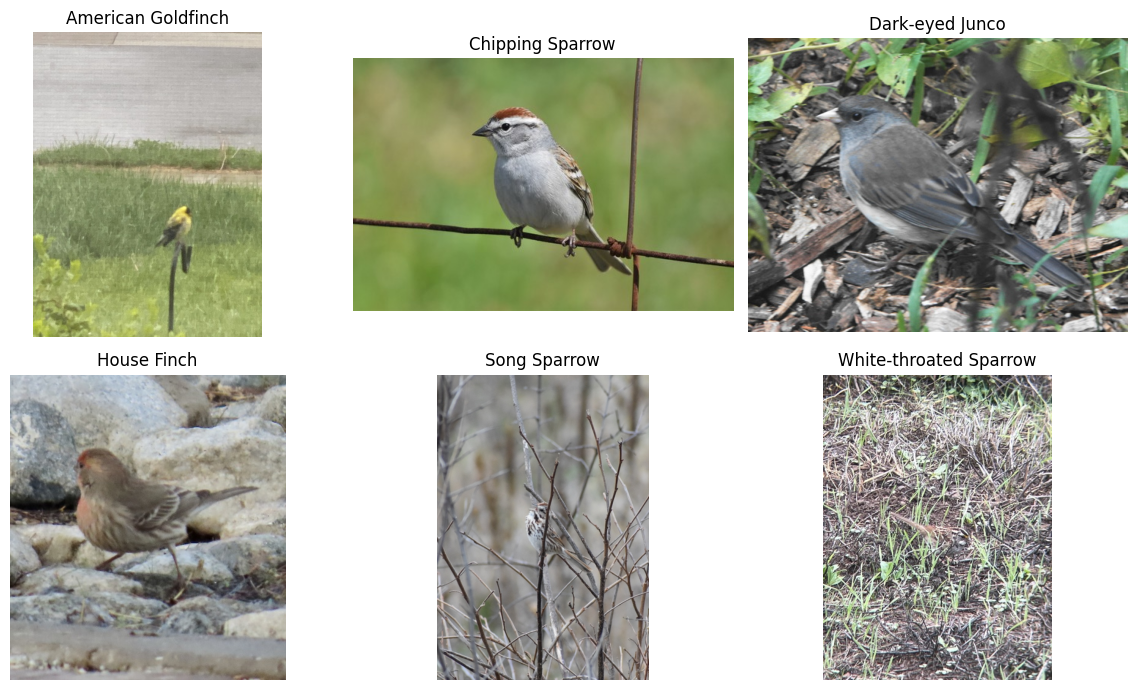

In [7]:
# @title Class counts and representative image gallery
import matplotlib.pyplot as plt

class_counts = (
    pd.DataFrame(records)
    .groupby(["split", "label"])
    .size()
    .unstack(fill_value=0)
)
display(class_counts)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, label in zip(axes.ravel(), class_names):
    record = next(r for r in splits["train"] if r["label"] == label)
    with Image.open(record["path"]) as image:
        ax.imshow(ImageOps.exif_transpose(image).convert("RGB"))
    ax.set_title(SPECIES.get(label, ("", label))[1] if label in SPECIES else label)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "figures" / "species_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Majority baseline

The built-in corpus is balanced, so the majority classifier should be near one-in-six accuracy. The notebook still calculates the baseline from the actual training labels instead of hard-coding it.

The baseline establishes the floor:

> Does the adapted representation contain useful information beyond always predicting the most common class?

> **Before you run it:** predict whether this simple reference will be easy or difficult for the learned model(s) to beat. After the result appears, record the baseline value before looking at the more complex model comparison.

**What to notice:** these are validation metrics. The most frequent training label is fixed without consulting held-out labels; its test score is deferred until Section 14. Accuracy counts correct labels, while macro-F1 gives each class equal weight.

In [8]:
# @title Majority baseline
from collections import Counter

train_labels = [r["label"] for r in splits["train"]]
validation_labels = [r["label"] for r in splits["validation"]]
majority_label, majority_count = Counter(train_labels).most_common(1)[0]

def basic_classification_metrics(y_true, y_pred, classes):
    classes = list(classes)
    index = {c: i for i, c in enumerate(classes)}
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for truth, pred in zip(y_true, y_pred):
        cm[index[truth], index[pred]] += 1
    per_class = []
    f1s = []
    for i, label in enumerate(classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        f1s.append(f1)
        per_class.append({
            "class": label, "precision": precision, "recall": recall,
            "f1": f1, "support": int(cm[i, :].sum()),
        })
    return {
        "accuracy": float(np.trace(cm) / cm.sum()),
        "macro_f1": float(np.mean(f1s)),
        "confusion": cm,
        "per_class": per_class,
    }

majority_validation_predictions = [majority_label] * len(validation_labels)
majority_validation_metrics = basic_classification_metrics(validation_labels, majority_validation_predictions, class_names)
print({
    "majority_label": majority_label,
    "training_fraction": majority_count / len(train_labels),
    "validation_accuracy": majority_validation_metrics["accuracy"],
    "validation_macro_f1": majority_validation_metrics["macro_f1"],
})

{'majority_label': 'white_throated_sparrow', 'training_fraction': 0.16666666666666666, 'validation_accuracy': 0.16666666666666666, 'validation_macro_f1': 0.047619047619047616}


## 7. Build the pinned model environments

Each model runs in a separate environment built with `uv`, which provides Python 3.12 whatever Python the notebook kernel uses. `STANDARD` models share the same qualified stack:

- Python 3.12
- PyTorch 2.14.0
- torchvision 0.29.0
- timm 1.0.29
- huggingface-hub 0.36.2
- SafeTensors 0.8.0
- NumPy 2.5.3
- Pillow 11.3.0

SwinV2's live carrier pins `timm==1.0.28` and Pillow 12.3.0, so `FULL` uses a separate Swin environment instead of silently changing its qualified runtime.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [9]:
# @title Create isolated pinned environments
import hashlib
import os
import shutil
import subprocess
import sys

MODEL_ENV_PYTHON = "3.12"
UV_PIN = "uv==0.8.17"

ENV_PINS = {
    "common": [
        "torch==2.14.0",
        "torchaudio==2.11.0",
        "torchvision==0.29.0",
        "timm==1.0.29",
        "huggingface-hub==0.36.2",
        "safetensors==0.8.0",
        "numpy==2.5.3",
        "pillow==11.3.0",
    ],
    "swin": [
        "torch==2.14.0",
        "torchaudio==2.11.0",
        "torchvision==0.29.0",
        "timm==1.0.28",
        "huggingface-hub==0.36.2",
        "safetensors==0.8.0",
        "numpy==2.5.3",
        "pillow==12.3.0",
    ],
}

def run_checked(cmd, label):
    """Run one step in a child process; on failure, show the tail of its output."""
    env = dict(os.environ)
    env["MPLBACKEND"] = "Agg"
    completed = subprocess.run(
        [str(part) for part in cmd], check=False, text=True, capture_output=True, env=env
    )
    if completed.returncode != 0:
        raise RuntimeError(
            f"{label} failed with exit code {completed.returncode}.\n"
            f"--- stderr (tail) ---\n{completed.stderr[-4000:]}\n"
            f"--- stdout (tail) ---\n{completed.stdout[-2000:]}"
        )
    return completed

def ensure_uv():
    probe = subprocess.run(
        [sys.executable, "-m", "uv", "--version"], check=False, capture_output=True, text=True
    )
    if probe.returncode != 0:
        run_checked([sys.executable, "-m", "pip", "install", "--quiet", UV_PIN], f"install {UV_PIN}")

def env_python(name):
    root = WORK_ROOT / "envs" / name
    return root / ("Scripts/python.exe" if os.name == "nt" else "bin/python")

def ensure_env(name):
    root = WORK_ROOT / "envs" / name
    python = env_python(name)
    signature = hashlib.sha256(
        "\n".join([f"python=={MODEL_ENV_PYTHON}", *ENV_PINS[name]]).encode()
    ).hexdigest()
    marker = root / ".dimer_ready"
    if python.is_file() and marker.is_file() and marker.read_text().strip() == signature:
        print(name, "reused")
        return python
    if root.exists():
        shutil.rmtree(root)
    run_checked(
        [sys.executable, "-m", "uv", "venv", "--seed", "--python", MODEL_ENV_PYTHON, str(root)],
        f"create the {name} environment",
    )
    run_checked(
        [str(python), "-m", "pip", "install", "--quiet", *ENV_PINS[name]],
        f"install the {name} environment pins",
    )
    marker.write_text(signature, encoding="utf-8")
    print(name, "ready")
    return python

ensure_uv()
needed_envs = sorted({MODEL_SPECS[m]["env"] for m in SELECTED_MODELS})
ENV_PYTHONS = {name: ensure_env(name) for name in needed_envs}
print({k: str(v) for k, v in ENV_PYTHONS.items()})

common ready
{'common': 'work/envs/common/bin/python'}


## 8. Standalone frozen-feature extractor

The feature runner:

1. stages only the manifest-listed files at the pinned Hugging Face revision;
2. verifies every file's byte size and SHA-256;
3. reads the pinned `config.json`;
4. rebuilds the registered `timm` architecture;
5. gives the verified local `model.safetensors` precedence over any Hub source;
6. uses `timm`'s model-native evaluation transform;
7. calls `forward_features` followed by `forward_head(..., pre_logits=True)`; and
8. exports one pooled penultimate representation per image.

The original ImageNet classifier head remains irrelevant to the six-species task.

**Infrastructure:** run the following cells as written; reading their implementation is optional.

A feature vector is a list of numbers describing an image. Frozen means the pretrained network weights stay unchanged; the new probe learns how those numbers map to this dataset’s labels.

In [10]:
# @title Write the generic feature-extraction runner
FEATURE_RUNNER = r"""
import argparse, csv, hashlib, json, platform, time
from pathlib import Path

import numpy as np

def sha(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1<<20),b""): h.update(chunk)
    return h.hexdigest()

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument("--spec",required=True)
    ap.add_argument("--dataset",required=True)
    ap.add_argument("--features",required=True)
    ap.add_argument("--metadata",required=True)
    ap.add_argument("--cache",required=True)
    args=ap.parse_args()

    spec=json.loads(Path(args.spec).read_text())
    root=Path(args.cache)
    root.mkdir(parents=True,exist_ok=True)

    from huggingface_hub import hf_hub_download
    for name,entry in spec["files"].items():
        p=Path(hf_hub_download(
            spec["model_id"], name, revision=spec["revision"], local_dir=str(root)
        ))
        if p.stat().st_size != int(entry[0]) or sha(p) != entry[1]:
            raise ValueError(f"{name}: integrity mismatch")

    config=json.loads((root/"config.json").read_text())
    arch_name=spec["model_id"].split("/",1)[1]
    snapshot_name=f"{config['architecture']}.{config['pretrained_cfg']['tag']}"
    if snapshot_name != arch_name:
        raise ValueError(f"snapshot architecture {snapshot_name!r} != expected {arch_name!r}")

    import torch, timm
    from PIL import Image, ImageOps
    from timm.data import create_transform, resolve_model_data_config

    device="cuda:0" if torch.cuda.is_available() else "cpu"
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    overlay=dict(config["pretrained_cfg"])
    overlay["file"]=str(root/"model.safetensors")
    started=time.perf_counter()
    model=timm.create_model(
        arch_name, pretrained=True, pretrained_cfg_overlay=overlay
    ).eval().to(device)
    data_config=resolve_model_data_config(model)
    transform=create_transform(**data_config,is_training=False)
    load_seconds=time.perf_counter()-started

    rows=list(csv.DictReader(open(args.dataset,encoding="utf-8")))
    ids=[]; labels=[]; splits=[]; features=[]
    batch_size=int(spec["batch_size"])
    started=time.perf_counter()
    for start in range(0,len(rows),batch_size):
        batch_rows=rows[start:start+batch_size]
        tensors=[]
        for row in batch_rows:
            with Image.open(row["path"]) as image:
                image.load()
                image=ImageOps.exif_transpose(image).convert("RGB")
                tensors.append(transform(image))
        x=torch.stack(tensors).to(device)
        with torch.inference_mode():
            z=model.forward_head(model.forward_features(x),pre_logits=True)
        if z.ndim != 2:
            raise RuntimeError(f"penultimate features must be 2D, got {tuple(z.shape)}")
        features.append(z.float().cpu().numpy())
        ids.extend(row["id"] for row in batch_rows)
        labels.extend(row["label"] for row in batch_rows)
        splits.extend(row["split"] for row in batch_rows)
    feature_seconds=time.perf_counter()-started
    feats=np.concatenate(features,axis=0).astype(np.float32)
    np.savez_compressed(
        args.features,
        features=feats,
        ids=np.asarray(ids,dtype="U128"),
        labels=np.asarray(labels,dtype="U128"),
        splits=np.asarray(splits,dtype="U32"),
    )
    peak=int(torch.cuda.max_memory_allocated()) if torch.cuda.is_available() else None
    meta={
        "key":spec["key"],"display_name":spec["display_name"],"family":spec["family"],
        "model_id":spec["model_id"],"revision":spec["revision"],"license":spec["license"],
        "device":device,"parameters":int(sum(p.numel() for p in model.parameters())),
        "feature_dimension":int(feats.shape[1]),"n_images":int(feats.shape[0]),
        "data_config":data_config,"native_input":spec["native_input"],
        "load_seconds":load_seconds,"feature_seconds":feature_seconds,
        "images_per_second":float(feats.shape[0]/feature_seconds),
        "peak_cuda_bytes":peak,"python":platform.python_version(),
        "timm":timm.__version__,"torch":torch.__version__,
        "weight_bytes":int(spec["files"]["model.safetensors"][0]),
        "weight_sha256":spec["files"]["model.safetensors"][1],
    }
    Path(args.metadata).write_text(json.dumps(meta,indent=2,default=str),encoding="utf-8")

if __name__=="__main__": main()
"""

feature_runner_path = WORK_ROOT / "runners" / "extract_features.py"
feature_runner_path.write_text(FEATURE_RUNNER, encoding="utf-8")
compile(FEATURE_RUNNER, str(feature_runner_path), "exec")
print("feature runner sha256:", hashlib.sha256(FEATURE_RUNNER.encode()).hexdigest())

feature runner sha256: 1b9194e463e09e1e851bc52e4cf7c13acf5013b359cc7ba6a773bb61af1b1147


## 9. Extract frozen features from every selected backbone

**Expected result:** one feature cache and metadata record per selected model. Feature dimensions can differ; image IDs and split membership must agree. The backbones run sequentially to limit GPU memory.

In [11]:
# @title Run feature extraction one model at a time
import json
import os
import subprocess
import time

feature_files = {}
feature_metadata = {}

for key in SELECTED_MODELS:
    spec = {**MODEL_SPECS[key], "key": key}
    spec_path = WORK_ROOT / "runners" / f"{key}_spec.json"
    spec_path.write_text(json.dumps(spec, indent=2), encoding="utf-8")
    feature_path = OUTPUT_ROOT / "features" / f"{key}.npz"
    meta_path = OUTPUT_ROOT / "features" / f"{key}.json"
    cache_dir = WORK_ROOT / "model_cache" / key
    python = ENV_PYTHONS[spec["env"]]
    cmd = [
        str(python), str(feature_runner_path),
        "--spec", str(spec_path),
        "--dataset", str(dataset_csv),
        "--features", str(feature_path),
        "--metadata", str(meta_path),
        "--cache", str(cache_dir),
    ]
    print("extracting:", key)
    started = time.perf_counter()
    completed = run_checked(cmd, f"feature extraction for {key}")
    wall_seconds = time.perf_counter() - started
    if completed.stdout.strip():
        print(completed.stdout[-1000:])
    meta = json.loads(meta_path.read_text())
    meta["wall_seconds"] = wall_seconds
    meta_path.write_text(json.dumps(meta, indent=2, default=str), encoding="utf-8")
    feature_files[key] = feature_path
    feature_metadata[key] = meta

display(pd.DataFrame([
    {
        "model": feature_metadata[k]["display_name"],
        "family": feature_metadata[k]["family"],
        "params_M": round(feature_metadata[k]["parameters"]/1e6, 2),
        "input": feature_metadata[k]["native_input"],
        "feature_dim": feature_metadata[k]["feature_dimension"],
        "images_per_second": feature_metadata[k]["images_per_second"],
        "peak_vram_MiB": (
            round(feature_metadata[k]["peak_cuda_bytes"]/2**20,1)
            if feature_metadata[k]["peak_cuda_bytes"] is not None else None
        ),
    }
    for k in SELECTED_MODELS
]))

extracting: mobilenet
extracting: resnet
extracting: convnext
extracting: vit


,model,family,params_M,input,feature_dim,images_per_second,peak_vram_MiB
0,MobileNetV4-Conv-Small,efficient CNN,3.77,224,1280,108.231515,133.1
1,ResNet-50,residual CNN,25.56,224,2048,94.707164,351.9
2,ConvNeXt-Tiny,modern ConvNet,28.59,224,768,74.265985,436.1
3,ViT-B/16,plain Vision Transformer,86.57,224,768,59.834406,467.6


## 10. Common linear-probe adaptation

The probe policy is identical across architectures:

- backbone frozen;
- z-score fitted **only on training features**;
- `Linear(feature_dim, n_classes)`;
- AdamW;
- learning rate `0.001`;
- weight decay `1e-4`;
- maximum 1000 steps;
- seed 0;
- cross-entropy loss;
- validation log-loss checked every 10 steps;
- lowest validation log-loss selects the probe.

The artifact contains only:

- probe weight;
- probe bias;
- feature mean;
- feature standard deviation.

It does **not** duplicate the pretrained backbone.

> **Why these settings.** With only 108 training images and 768–2,048 standardized features, every probe can fit the training set almost perfectly. At a learning rate of `0.01` that happened within the first 10 steps, validation log-loss only rose after that, and every model was "selected" at its first checkpoint — the selection rule never got to choose. At `0.001` each probe reaches its validation minimum at its own step. The training cell reports when a selection lands on the first checkpoint or on the step cap, because either means the rule could not see a true minimum.

**Core concept:** a linear probe assigns a weighted sum of features to each class. Train-only z-scoring subtracts a training mean and divides by a training standard deviation; validation and test reuse those statistics. Log-loss penalizes confident wrong predictions more strongly than accuracy does.

In [12]:
# @title Write the common probe-training runner
PROBE_TRAIN_RUNNER = r"""
import argparse, csv, hashlib, json, math, time
from pathlib import Path
import numpy as np
import torch
from safetensors.torch import save_file, load_file

def sha(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1<<20),b""): h.update(chunk)
    return h.hexdigest()

def softmax_probs(head,x):
    with torch.inference_mode():
        return torch.softmax(head(x),dim=1).cpu().numpy()

def write_predictions(path, ids, labels, probs, classes):
    with open(path,"w",encoding="utf-8",newline="") as handle:
        fields=["id","truth","prediction",*[f"prob_{c}" for c in classes]]
        w=csv.DictWriter(handle,fieldnames=fields); w.writeheader()
        for rid,truth,p in zip(ids,labels,probs):
            pred=classes[int(np.argmax(p))]
            row={"id":rid,"truth":truth,"prediction":pred}
            row.update({f"prob_{c}":float(p[i]) for i,c in enumerate(classes)})
            w.writerow(row)

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument("--features",required=True)
    ap.add_argument("--model-meta",required=True)
    ap.add_argument("--artifact-dir",required=True)
    ap.add_argument("--val-predictions",required=True)
    ap.add_argument("--training-report",required=True)
    ap.add_argument("--steps",type=int,default=1000)
    ap.add_argument("--lr",type=float,default=1e-3)
    ap.add_argument("--weight-decay",type=float,default=1e-4)
    ap.add_argument("--seed",type=int,default=0)
    args=ap.parse_args()

    data=np.load(args.features,allow_pickle=False)
    X=data["features"].astype(np.float32)
    ids=data["ids"].astype(str); labels=data["labels"].astype(str); splits=data["splits"].astype(str)
    classes=sorted(set(labels.tolist()))
    class_to_idx={c:i for i,c in enumerate(classes)}
    y=np.asarray([class_to_idx[x] for x in labels],dtype=np.int64)

    train=splits=="train"; val=splits=="validation"
    if train.sum()<2 or val.sum()<1: raise ValueError("train/validation features missing")
    mean=X[train].mean(axis=0).astype(np.float32)
    std=X[train].std(axis=0).astype(np.float32)
    std=np.where(std<1e-6,1.0,std).astype(np.float32)
    Xn=((X-mean)/std).astype(np.float32)

    xt=torch.from_numpy(Xn[train])
    yt=torch.from_numpy(y[train])
    xv=torch.from_numpy(Xn[val])
    yv=torch.from_numpy(y[val])

    torch.manual_seed(args.seed)
    head=torch.nn.Linear(X.shape[1],len(classes))
    optimizer=torch.optim.AdamW(head.parameters(),lr=args.lr,weight_decay=args.weight_decay)
    loss_fn=torch.nn.CrossEntropyLoss()

    best_loss=math.inf; best_step=None; best_state=None; history=[]
    started=time.perf_counter()
    for step in range(1,args.steps+1):
        head.train()
        logits=head(xt); loss=loss_fn(logits,yt)
        optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
        if step % 10 == 0 or step == args.steps:
            head.eval()
            with torch.inference_mode():
                v_logits=head(xv); v_loss=float(loss_fn(v_logits,yv))
                v_acc=float((v_logits.argmax(1)==yv).float().mean())
            history.append({"step":step,"train_loss":float(loss.detach()),"val_log_loss":v_loss,"val_accuracy":v_acc})
            if v_loss < best_loss:
                best_loss=v_loss; best_step=step
                best_state={k:v.detach().clone() for k,v in head.state_dict().items()}
    if best_state is None: raise RuntimeError("no probe checkpoint selected")
    head.load_state_dict(best_state); head.eval()

    val_probs=softmax_probs(head,xv)
    artifact=Path(args.artifact_dir); artifact.mkdir(parents=True,exist_ok=True)
    weights=artifact/"adapter.safetensors"
    save_file({
        "head.weight":head.weight.detach().contiguous(),
        "head.bias":head.bias.detach().contiguous(),
        "feature_mean":torch.from_numpy(mean).contiguous(),
        "feature_std":torch.from_numpy(std).contiguous(),
    },str(weights),metadata={"format":"pt"})

    model_meta=json.loads(Path(args.model_meta).read_text())
    manifest={
        "format":"org.dimer.common-linear-probe.v1","format_version":"1.0",
        "base_model":{
            "id":model_meta["model_id"],"revision":model_meta["revision"],
            "weight_sha256":model_meta["weight_sha256"],
        },
        "classes":classes,"class_order":classes,"feature_dimension":int(X.shape[1]),
        "adaptation":{
            "method":"frozen backbone + train-feature z-score + linear probe",
            "steps":args.steps,"learning_rate":args.lr,"weight_decay":args.weight_decay,
            "seed":args.seed,"selection":"lowest validation log-loss",
            "selected_step":best_step,"selected_val_log_loss":best_loss,
        },
        "files":[{"path":"adapter.safetensors","bytes":weights.stat().st_size,"sha256":sha(weights)}],
        "history":history,
    }
    (artifact/"manifest.json").write_text(json.dumps(manifest,indent=2),encoding="utf-8")

    # Fresh-boundary verification on validation features.
    loaded=load_file(str(weights))
    reloaded=torch.nn.Linear(X.shape[1],len(classes))
    reloaded.load_state_dict({"weight":loaded["head.weight"],"bias":loaded["head.bias"]},strict=True)
    reloaded.eval()
    mean2=loaded["feature_mean"].numpy(); std2=loaded["feature_std"].numpy()
    xv2=torch.from_numpy(((X[val]-mean2)/std2).astype(np.float32))
    val_probs_reloaded=softmax_probs(reloaded,xv2)
    max_diff=float(np.max(np.abs(val_probs_reloaded-val_probs)))
    if max_diff > 1e-6:
        raise RuntimeError(f"fresh reload probability mismatch: {max_diff}")
    write_predictions(args.val_predictions,ids[val],labels[val],val_probs_reloaded,classes)

    checkpoints=[h["step"] for h in history]
    report={
        "selected_step":best_step,"selected_val_log_loss":best_loss,
        # A selection on the first checkpoint or on the step cap means the rule saw no interior minimum.
        "selected_at_first_checkpoint":best_step==checkpoints[0],
        "selected_at_step_cap":best_step==checkpoints[-1],
        "steps":args.steps,"learning_rate":args.lr,"weight_decay":args.weight_decay,
        "seed":args.seed,"train_records":int(train.sum()),"validation_records":int(val.sum()),
        "feature_dimension":int(X.shape[1]),"classes":classes,
        "seconds":time.perf_counter()-started,
        "fresh_reload_max_abs_probability_difference":max_diff,
        "history":history,
    }
    Path(args.training_report).write_text(json.dumps(report,indent=2),encoding="utf-8")

if __name__=="__main__": main()
"""

PROBE_INFER_RUNNER = r"""
import argparse,csv,json
from pathlib import Path
import numpy as np
import torch
from safetensors.torch import load_file

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument("--features",required=True)
    ap.add_argument("--artifact-dir",required=True)
    ap.add_argument("--split",required=True)
    ap.add_argument("--predictions",required=True)
    args=ap.parse_args()

    data=np.load(args.features,allow_pickle=False)
    X=data["features"].astype(np.float32)
    ids=data["ids"].astype(str); labels=data["labels"].astype(str); splits=data["splits"].astype(str)
    manifest=json.loads((Path(args.artifact_dir)/"manifest.json").read_text())
    classes=list(manifest["class_order"])
    selected=splits==args.split
    tensors=load_file(str(Path(args.artifact_dir)/"adapter.safetensors"))
    mean=tensors["feature_mean"].numpy(); std=tensors["feature_std"].numpy()
    x=torch.from_numpy(((X[selected]-mean)/std).astype(np.float32))
    head=torch.nn.Linear(X.shape[1],len(classes))
    head.load_state_dict({"weight":tensors["head.weight"],"bias":tensors["head.bias"]},strict=True)
    head.eval()
    with torch.inference_mode():
        probs=torch.softmax(head(x),dim=1).numpy()
    with open(args.predictions,"w",encoding="utf-8",newline="") as handle:
        fields=["id","truth","prediction",*[f"prob_{c}" for c in classes]]
        w=csv.DictWriter(handle,fieldnames=fields); w.writeheader()
        for rid,truth,p in zip(ids[selected],labels[selected],probs):
            row={"id":rid,"truth":truth,"prediction":classes[int(np.argmax(p))]}
            row.update({f"prob_{c}":float(p[i]) for i,c in enumerate(classes)})
            w.writerow(row)

if __name__=="__main__": main()
"""

probe_train_path=WORK_ROOT/"runners"/"train_probe.py"
probe_infer_path=WORK_ROOT/"runners"/"infer_probe.py"
probe_train_path.write_text(PROBE_TRAIN_RUNNER,encoding="utf-8")
probe_infer_path.write_text(PROBE_INFER_RUNNER,encoding="utf-8")
compile(PROBE_TRAIN_RUNNER,str(probe_train_path),"exec")
compile(PROBE_INFER_RUNNER,str(probe_infer_path),"exec")
print({
    "train_probe_sha256":hashlib.sha256(PROBE_TRAIN_RUNNER.encode()).hexdigest(),
    "infer_probe_sha256":hashlib.sha256(PROBE_INFER_RUNNER.encode()).hexdigest(),
})

{'train_probe_sha256': '601dfc75318cb17cb18d5e3f1360a695b08aef2a9dea603f514ddda3c61d627b', 'infer_probe_sha256': '32d7e5836aa63d1e61aa66f50dfcd7f376ab2ca69608b9ce061bdf49ab9d45c7'}


## 11. Train/select probes using training and validation only

**Predict before running:** which pretrained system will have the lowest validation log-loss? State a reason, then compare with Sections 11–12. Notice selected step and reload difference: a boundary selection does not establish a true optimum; serialization should preserve probabilities within the runner’s tolerance.

In [13]:
# @title Train the common probe and verify serialized reload on validation
import subprocess
import time

probe_reports={}
validation_prediction_files={}
common_python=ENV_PYTHONS["common"]

for key in SELECTED_MODELS:
    artifact_dir=OUTPUT_ROOT/"artifacts"/key
    val_predictions=OUTPUT_ROOT/"validation"/f"{key}.csv"
    training_report=OUTPUT_ROOT/"validation"/f"{key}_training.json"
    cmd=[
        str(common_python),str(probe_train_path),
        "--features",str(feature_files[key]),
        "--model-meta",str(OUTPUT_ROOT/"features"/f"{key}.json"),
        "--artifact-dir",str(artifact_dir),
        "--val-predictions",str(val_predictions),
        "--training-report",str(training_report),
        "--steps",str(PROBE_STEPS),
        "--lr",str(PROBE_LR),
        "--weight-decay",str(PROBE_WEIGHT_DECAY),
        "--seed",str(PROBE_SEED),
    ]
    print("probe:",key)
    run_checked(cmd,f"probe training for {key}")
    report=json.loads(training_report.read_text())
    probe_reports[key]=report
    validation_prediction_files[key]=val_predictions

display(pd.DataFrame([
    {
        "model":MODEL_SPECS[k]["display_name"],
        "selected_step":probe_reports[k]["selected_step"],
        "val_log_loss":probe_reports[k]["selected_val_log_loss"],
        "at_first_checkpoint":probe_reports[k]["selected_at_first_checkpoint"],
        "at_step_cap":probe_reports[k]["selected_at_step_cap"],
        "reload_max_abs_diff":probe_reports[k]["fresh_reload_max_abs_probability_difference"],
    }
    for k in SELECTED_MODELS
]))
for k in SELECTED_MODELS:
    if probe_reports[k]["selected_at_first_checkpoint"]:
        print(f"Note: {k} was selected at its first checkpoint; its validation minimum may lie earlier (probe learning rate too high for this sample).")

probe: mobilenet
probe: resnet
probe: convnext
probe: vit


,model,selected_step,val_log_loss,at_first_checkpoint,at_step_cap,reload_max_abs_diff
0,MobileNetV4-Conv-Small,50,0.978178,False,False,0.0
1,ResNet-50,30,0.813706,False,False,0.0
2,ConvNeXt-Tiny,1000,0.104703,False,True,0.0
3,ViT-B/16,1000,0.131872,False,True,0.0


## 12. Validation comparison

Validation selects the probe checkpoint; it is not final evidence.

The same metrics are computed for each architecture:

- accuracy;
- macro-F1;
- multiclass log-loss;
- per-class precision/recall/F1.

The optional DINOv2 result, when enabled, is reported separately as a self-supervised representation baseline.

> **What to notice.** Compare the model result with the stated baseline/reference first. Then inspect the secondary metric or diagnostic that explains *how* the result was achieved; do not infer a universal model ranking from one sample and configuration.

**Checkpoint:** why can the highest-accuracy model have worse log-loss?

<details><summary>Sample interpretation</summary>
Accuracy only counts the chosen class. Log-loss also measures the score assigned to the true class, so a few confident errors can outweigh more correct labels. Compare metrics on the same validation rows; this is selection evidence, not a final test claim.
</details>

In [14]:
# @title Common validation evaluator
def evaluate_prediction_csv(path, classes):
    pred=pd.read_csv(path)
    metrics=basic_classification_metrics(pred["truth"],pred["prediction"],classes)
    eps=1e-12
    class_to_idx={c:i for i,c in enumerate(classes)}
    probs=pred[[f"prob_{c}" for c in classes]].to_numpy(dtype=float)
    y=np.asarray([class_to_idx[x] for x in pred["truth"]],dtype=int)
    log_loss=float(-np.mean(np.log(np.clip(probs[np.arange(len(y)),y],eps,1.0))))
    metrics["log_loss"]=log_loss
    return pred,metrics

validation_metrics={}
for key,path in validation_prediction_files.items():
    pred,metrics=evaluate_prediction_csv(path,class_names)
    validation_metrics[key]=metrics

validation_table=pd.DataFrame([
    {
        "model":MODEL_SPECS[k]["display_name"],
        "group":"self-supervised baseline" if k=="dinov2" else "core",
        "accuracy":validation_metrics[k]["accuracy"],
        "macro_f1":validation_metrics[k]["macro_f1"],
        "log_loss":validation_metrics[k]["log_loss"],
    }
    for k in SELECTED_MODELS
])
display(validation_table)
validation_table.to_csv(OUTPUT_ROOT/"validation"/"metrics.csv",index=False)

,model,group,accuracy,macro_f1,log_loss
0,MobileNetV4-Conv-Small,core,0.625000,0.647234,0.978178
1,ResNet-50,core,0.708333,0.684127,0.813706
2,ConvNeXt-Tiny,core,0.958333,0.957672,0.104703
3,ViT-B/16,core,0.958333,0.957672,0.131872


## 13. Freeze before the independent test

The following record captures:

- dataset identity and split;
- selected architecture set;
- model revisions and weight digests;
- native preprocessing metadata;
- feature dimensions;
- common probe hyperparameters;
- selected probe step;
- adapter digests; and
- validation metrics.

Only after this file is written does the notebook create test predictions.

**Predict before test:** will the validation ordering persist on unseen test images? Record the prediction now. After Section 14, explain a difference without changing model selection or refreezing in response.

In [15]:
# @title Freeze experiment
def artifact_digest(key):
    return sha256_file(OUTPUT_ROOT/"artifacts"/key/"adapter.safetensors")

frozen={
    "notebook_spec":"2.1",
    "profile":"E2E",
    "mode":"WORKSHOP",
    "execution_tier":WORKSHOP_TIER,
    "dataset":dataset_manifest,
    "core_models":CORE_MODELS,
    "dinov2_extension":RUN_DINOV2_EXTENSION,
    "models":{
        key:{
            "model_id":MODEL_SPECS[key]["model_id"],
            "revision":MODEL_SPECS[key]["revision"],
            "weight_sha256":MODEL_SPECS[key]["files"]["model.safetensors"][1],
            "native_input":MODEL_SPECS[key]["native_input"],
            "feature_dimension":feature_metadata[key]["feature_dimension"],
            "data_config":feature_metadata[key]["data_config"],
            "probe_selected_step":probe_reports[key]["selected_step"],
            "probe_artifact_sha256":artifact_digest(key),
        }
        for key in SELECTED_MODELS
    },
    "probe":{
        "method":"frozen backbone + train-feature z-score + linear probe",
        "steps":PROBE_STEPS,"learning_rate":PROBE_LR,
        "weight_decay":PROBE_WEIGHT_DECAY,"seed":PROBE_SEED,
        "selection":"lowest validation log-loss, evaluated every 10 steps",
    },
    "validation_metrics":validation_table.to_dict("records"),
}
freeze_path=OUTPUT_ROOT/"frozen"/"frozen_experiment.json"
freeze_path.write_text(json.dumps(frozen,indent=2,default=str),encoding="utf-8")
print("Frozen:",freeze_path)

Frozen: outputs/frozen/frozen_experiment.json


# 14. Independent held-out test

**Evaluation practice:** the frozen adapters and fixed majority rule are now scored on the held-out test split. Compare like-for-like test accuracy and macro-F1 with the majority reference printed here. One test photograph changes built-in accuracy by about 2.1 percentage points; small differences are weak evidence.

In [16]:
# @title Reload each frozen adapter and score test features
frozen_loaded=json.loads((OUTPUT_ROOT/"frozen"/"frozen_experiment.json").read_text())
assert frozen_loaded["dataset"]["dataset_digest"]==dataset_digest
assert frozen_loaded["core_models"]==CORE_MODELS
assert frozen_loaded["dinov2_extension"]==RUN_DINOV2_EXTENSION

test_prediction_files={}
for key in SELECTED_MODELS:
    assert frozen_loaded["models"][key]["revision"]==MODEL_SPECS[key]["revision"]
    assert frozen_loaded["models"][key]["probe_artifact_sha256"]==artifact_digest(key)
    out=OUTPUT_ROOT/"test"/f"{key}.csv"
    cmd=[
        str(common_python),str(probe_infer_path),
        "--features",str(feature_files[key]),
        "--artifact-dir",str(OUTPUT_ROOT/"artifacts"/key),
        "--split","test",
        "--predictions",str(out),
    ]
    run_checked(cmd,f"test scoring for {key}")
    test_prediction_files[key]=out

test_metrics={}
test_predictions={}
per_class_rows=[]
for key,path in test_prediction_files.items():
    pred,metrics=evaluate_prediction_csv(path,class_names)
    test_predictions[key]=pred
    test_metrics[key]=metrics
    for row in metrics["per_class"]:
        per_class_rows.append({"model":MODEL_SPECS[key]["display_name"],**row})

test_table=pd.DataFrame([
    {
        "model":MODEL_SPECS[k]["display_name"],
        "family":MODEL_SPECS[k]["family"],
        "group":"self-supervised baseline" if k=="dinov2" else "core",
        "params_M":feature_metadata[k]["parameters"]/1e6,
        "native_input":MODEL_SPECS[k]["native_input"],
        "feature_dim":feature_metadata[k]["feature_dimension"],
        "accuracy":test_metrics[k]["accuracy"],
        "macro_f1":test_metrics[k]["macro_f1"],
        "log_loss":test_metrics[k]["log_loss"],
        "feature_seconds":feature_metadata[k]["feature_seconds"],
        "images_per_second":feature_metadata[k]["images_per_second"],
        "peak_vram_MiB":(
            feature_metadata[k]["peak_cuda_bytes"]/2**20
            if feature_metadata[k]["peak_cuda_bytes"] is not None else None
        ),
    }
    for k in SELECTED_MODELS
])

core_test_table=test_table[test_table["group"]=="core"].copy()
display(core_test_table)
if RUN_DINOV2_EXTENSION:
    print("Optional self-supervised representation baseline:")
    display(test_table[test_table["group"]!="core"])

core_test_table.to_csv(OUTPUT_ROOT/"test"/"aggregate_metrics.csv",index=False)
pd.DataFrame(per_class_rows).to_csv(OUTPUT_ROOT/"test"/"per_class_metrics.csv",index=False)

# Score the fixed training-derived reference only after the frozen test evaluation.
test_labels = [r["label"] for r in splits["test"]]
majority_predictions = [majority_label] * len(test_labels)
majority_metrics = basic_classification_metrics(test_labels, majority_predictions, class_names)
print({"majority_label": majority_label, "test_accuracy": majority_metrics["accuracy"],
       "test_macro_f1": majority_metrics["macro_f1"]})

,model,family,group,params_M,native_input,feature_dim,accuracy,macro_f1,log_loss,feature_seconds,images_per_second,peak_vram_MiB
0,MobileNetV4-Conv-Small,efficient CNN,core,3.774024,224,1280,0.500000,0.503560,1.520166,1.663102,108.231515,133.071777
1,ResNet-50,residual CNN,core,25.557032,224,2048,0.500000,0.480254,1.775193,1.900595,94.707164,351.853027
2,ConvNeXt-Tiny,modern ConvNet,core,28.589128,224,768,0.708333,0.710140,1.170479,2.423721,74.265985,436.129395
3,ViT-B/16,plain Vision Transformer,core,86.567656,224,768,0.770833,0.770400,0.888160,3.008303,59.834406,467.635742


{'majority_label': 'white_throated_sparrow', 'test_accuracy': 0.16666666666666666, 'test_macro_f1': 0.047619047619047616}


## 15. Confusion matrices and architecture disagreements

Aggregate accuracy can hide very different error patterns.

This notebook therefore inspects:

- per-class confusion;
- images every model gets right;
- images every model gets wrong;
- CNN/transformer disagreements; and
- architecture-specific successes.

Error-gallery selection is rule-based rather than manually cherry-picked.

**Checkpoint:** revisit the species pair you predicted in Section 5. Does its confusion appear for all models or only some?

<details><summary>Sample interpretation</summary>
Shared errors may reflect difficult views or limited data; a model-specific error may reflect its representation or crop. The gallery suggests hypotheses, not a causal explanation. Report counts and an example before proposing a follow-up.
</details>

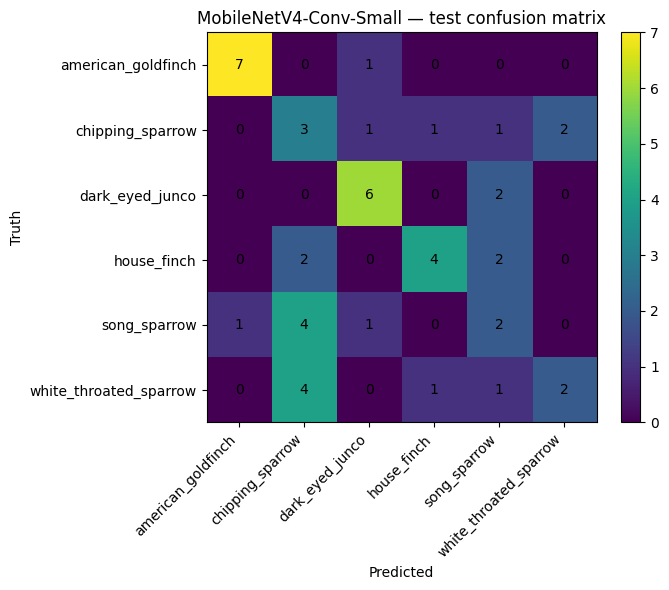

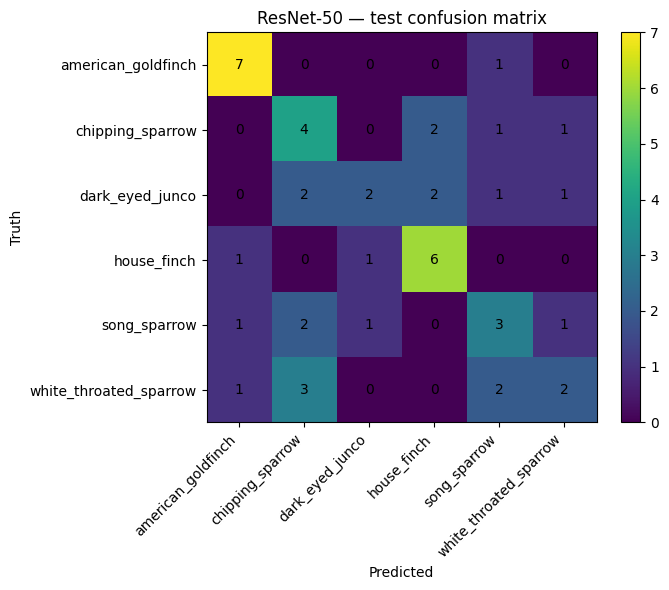

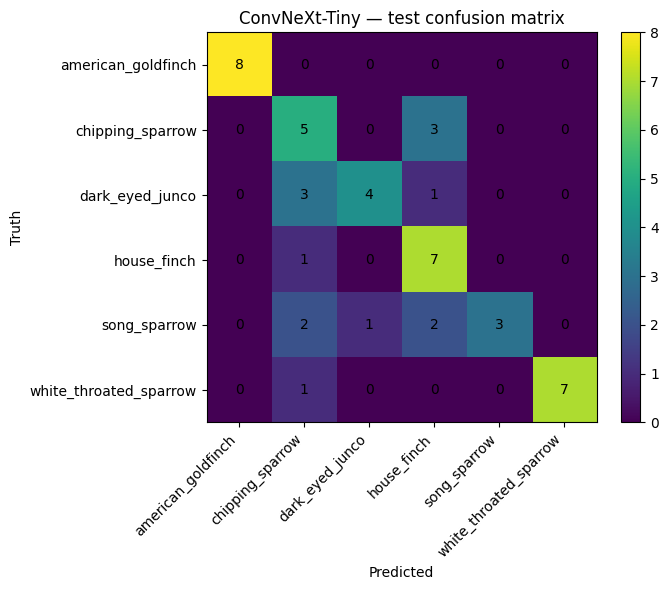

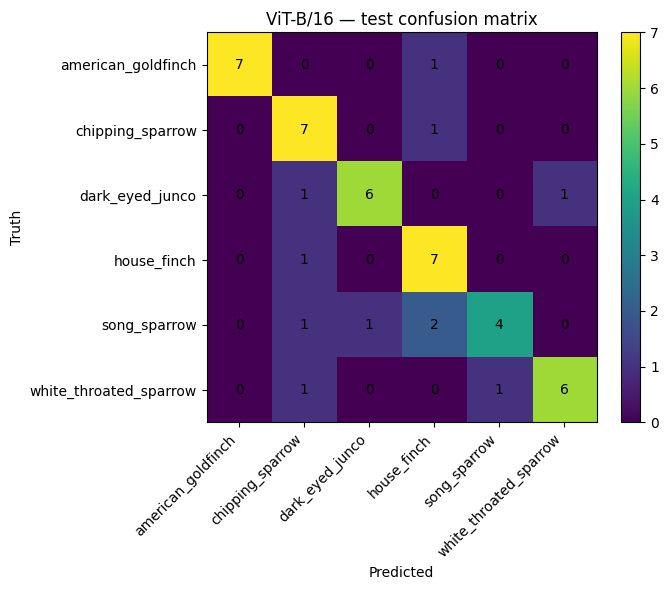

In [17]:
# @title Confusion matrices
fig_count=len(CORE_MODELS)
for key in CORE_MODELS:
    cm=test_metrics[key]["confusion"]
    fig,ax=plt.subplots(figsize=(7,6))
    im=ax.imshow(cm)
    ax.set_xticks(range(len(class_names)),class_names,rotation=45,ha="right")
    ax.set_yticks(range(len(class_names)),class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Truth")
    ax.set_title(f"{MODEL_SPECS[key]['display_name']} — test confusion matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center")
    plt.colorbar(im,ax=ax,fraction=0.046)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT/"figures"/f"confusion_{key}.png",dpi=150,bbox_inches="tight")
    plt.show()

In [18]:
# @title Cross-model disagreement table
base=test_predictions[CORE_MODELS[0]][["id","truth"]].copy()
for key in CORE_MODELS:
    pred=test_predictions[key][["id","prediction"]].rename(
        columns={"prediction":f"{key}_prediction"}
    )
    base=base.merge(pred,on="id",how="inner",validate="one_to_one")

prediction_cols=[f"{k}_prediction" for k in CORE_MODELS]
base["n_correct"]=sum(base[c]==base["truth"] for c in prediction_cols)
base["n_unique_predictions"]=base[prediction_cols].nunique(axis=1)
base["all_correct"]=base["n_correct"]==len(CORE_MODELS)
base["all_wrong"]=base["n_correct"]==0

disagreements=base.sort_values(
    ["n_unique_predictions","n_correct"],ascending=[False,True]
).reset_index(drop=True)
disagreements.to_csv(OUTPUT_ROOT/"test"/"disagreements.csv",index=False)

print({
    "unanimous_correct":int(base["all_correct"].sum()),
    "unanimous_wrong":int(base["all_wrong"].sum()),
    "any_model_disagreement":int((base["n_unique_predictions"]>1).sum()),
})
display(disagreements.head(12))

{'unanimous_correct': 15, 'unanimous_wrong': 5, 'any_model_disagreement': 32}


,id,truth,mobilenet_prediction,resnet_prediction,convnext_prediction,vit_prediction,n_correct,n_unique_predictions,all_correct,all_wrong
0,test-016,white_throated_sparrow,chipping_sparrow,american_goldfinch,white_throated_sparrow,song_sparrow,1,4,False,False
1,test-028,american_goldfinch,dark_eyed_junco,song_sparrow,american_goldfinch,house_finch,1,4,False,False
2,test-045,dark_eyed_junco,song_sparrow,chipping_sparrow,house_finch,dark_eyed_junco,1,4,False,False
3,test-039,dark_eyed_junco,song_sparrow,chipping_sparrow,chipping_sparrow,white_throated_sparrow,0,3,False,True
4,test-006,song_sparrow,american_goldfinch,song_sparrow,house_finch,house_finch,1,3,False,False
5,test-009,dark_eyed_junco,dark_eyed_junco,song_sparrow,chipping_sparrow,chipping_sparrow,1,3,False,False
6,test-000,chipping_sparrow,song_sparrow,white_throated_sparrow,chipping_sparrow,chipping_sparrow,2,3,False,False
7,test-002,song_sparrow,chipping_sparrow,white_throated_sparrow,song_sparrow,song_sparrow,2,3,False,False
8,test-003,white_throated_sparrow,house_finch,white_throated_sparrow,white_throated_sparrow,chipping_sparrow,2,3,False,False
9,test-011,chipping_sparrow,chipping_sparrow,song_sparrow,house_finch,chipping_sparrow,2,3,False,False


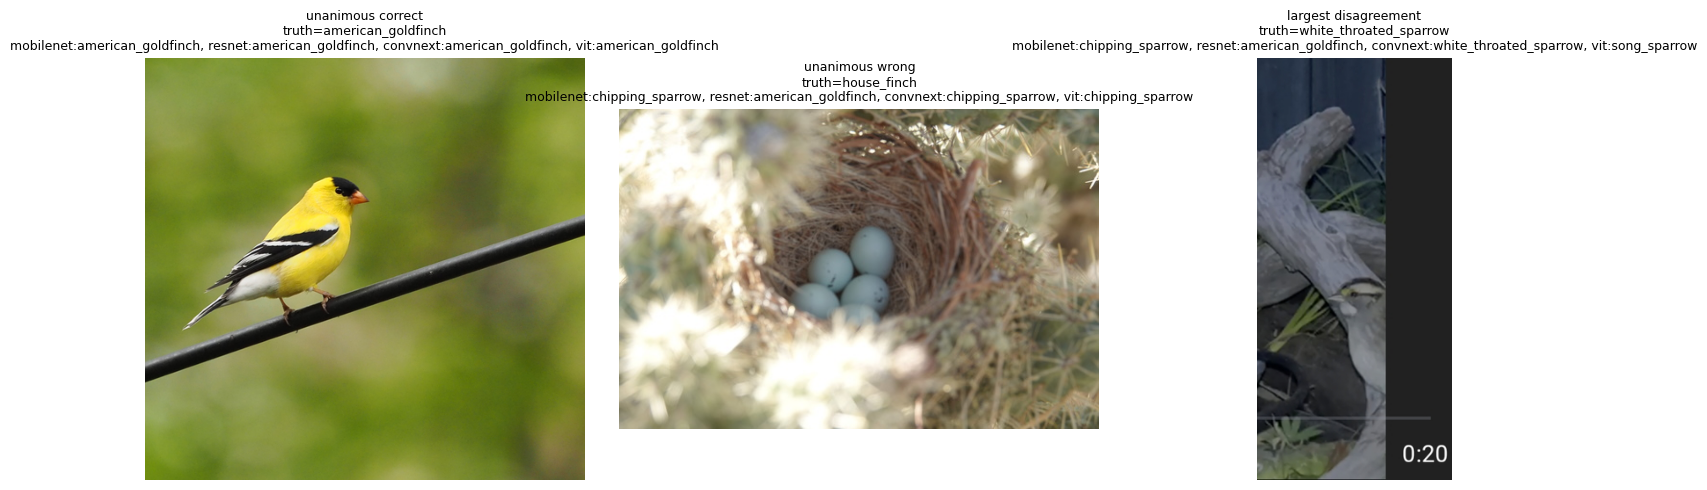

In [19]:
# @title Deterministic error gallery
record_by_id={r["id"]:r for r in records}

gallery_ids=[]
rules=[
    ("unanimous correct",base[base["all_correct"]]),
    ("unanimous wrong",base[base["all_wrong"]]),
    ("largest disagreement",disagreements[disagreements["n_unique_predictions"]==disagreements["n_unique_predictions"].max()]),
]
for label,table in rules:
    if len(table):
        gallery_ids.append((label,table.iloc[0]["id"]))

if gallery_ids:
    fig,axes=plt.subplots(1,len(gallery_ids),figsize=(5*len(gallery_ids),5))
    if len(gallery_ids)==1:
        axes=[axes]
    for ax,(rule,rid) in zip(axes,gallery_ids):
        record=record_by_id[rid]
        with Image.open(record["path"]) as image:
            ax.imshow(ImageOps.exif_transpose(image).convert("RGB"))
        row=base[base["id"]==rid].iloc[0]
        predictions=", ".join(f"{k}:{row[f'{k}_prediction']}" for k in CORE_MODELS)
        ax.set_title(f"{rule}\ntruth={row['truth']}\n{predictions}",fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT/"figures"/"error_gallery.png",dpi=150,bbox_inches="tight")
    plt.show()

## 16. Computational tradeoffs

The most accurate representation is not automatically the most appropriate deployment choice.

Inspect:

- parameter count;
- checkpoint size;
- native input resolution;
- feature dimension;
- extraction speed;
- peak accelerator memory;
- accuracy;
- macro-F1.

No composite score or overall winner is generated.

`accuracy / million parameters` is shown only as a teaching heuristic; it is not a definitive efficiency metric.

In [20]:
# @title Architecture / compute comparison
tradeoff=core_test_table.copy()
tradeoff["weight_MiB"]=[
    MODEL_SPECS[k]["files"]["model.safetensors"][0]/2**20 for k in CORE_MODELS
]
tradeoff["accuracy_per_M_params"]=tradeoff["accuracy"]/tradeoff["params_M"]
display(tradeoff[[
    "model","family","params_M","weight_MiB","native_input","feature_dim",
    "accuracy","macro_f1","feature_seconds","images_per_second",
    "peak_vram_MiB","accuracy_per_M_params"
]])
tradeoff.to_csv(OUTPUT_ROOT/"test"/"computational_tradeoffs.csv",index=False)

,model,family,params_M,weight_MiB,native_input,feature_dim,accuracy,macro_f1,feature_seconds,images_per_second,peak_vram_MiB,accuracy_per_M_params
0,MobileNetV4-Conv-Small,efficient CNN,3.774024,14.517799,224,1280,0.500000,0.503560,1.663102,108.231515,133.071777,0.132485
1,ResNet-50,residual CNN,25.557032,97.722855,224,2048,0.500000,0.480254,1.900595,94.707164,351.853027,0.019564
2,ConvNeXt-Tiny,modern ConvNet,28.589128,109.075806,224,768,0.708333,0.710140,2.423721,74.265985,436.129395,0.024776
3,ViT-B/16,plain Vision Transformer,86.567656,330.242838,224,768,0.770833,0.770400,3.008303,59.834406,467.635742,0.008904


## 17. Fresh-reloaded inference examples

Every test prediction above was produced **after** the common probe artifact was serialized and reloaded.

The next view treats a few held-out test photographs as new inputs relative to adaptation and compares the frozen six-class heads across architectures.

Softmax scores from these heads are **not calibrated correctness probabilities**.

In [21]:
# @title Compare fresh-reloaded predictions for selected held-out images
example_ids=list(test_predictions[CORE_MODELS[0]]["id"].head(3))
rows=[]
for rid in example_ids:
    row={"id":rid,"truth":test_predictions[CORE_MODELS[0]].set_index("id").loc[rid,"truth"]}
    for key in CORE_MODELS:
        p=test_predictions[key].set_index("id").loc[rid]
        row[MODEL_SPECS[key]["display_name"]]=p["prediction"]
    rows.append(row)
display(pd.DataFrame(rows))

,id,truth,MobileNetV4-Conv-Small,ResNet-50,ConvNeXt-Tiny,ViT-B/16
0,test-000,chipping_sparrow,song_sparrow,white_throated_sparrow,chipping_sparrow,chipping_sparrow
1,test-001,american_goldfinch,american_goldfinch,american_goldfinch,american_goldfinch,american_goldfinch
2,test-002,song_sparrow,chipping_sparrow,white_throated_sparrow,song_sparrow,song_sparrow


# 18. Bring Your Own Data

The BYOD branch enters at dataset acquisition and then follows the exact same local sequence:

```text
validate
→ deterministic stratified split
→ model-native feature extraction
→ train-feature normalization
→ common linear probe
→ validation selection
→ freeze
→ held-out test
→ adapter export/reload
```

This implements the `E2E` BYOD path through adaptation and evaluation; full positive/negative hosted execution evidence is still required.

### Important split assumption

The automatic BYOD split is image-level stratification.

That assumes images are sufficiently independent.

For datasets containing repeated:

- people;
- patients;
- individual animals;
- photographers;
- sites;
- videos;
- camera traps;

this notebook’s automatic image-level split does not enforce group independence. Pre-split directories or an extra split column are not consumed as fixed assignments. Use an explicitly group-aware extension and validate it before treating those metrics as independent evidence.

### Privacy

Images are processed in the selected notebook runtime, not sent to a DIMER worker or API. A hosted notebook remains an external compute environment. Do not upload confidential, personal, biometric, restricted, regulated, or proprietary imagery unless authorized.

# 19. Optional DINOv2 representation baseline

When `RUN_DINOV2_EXTENSION=True`, the notebook runs:

`DINOv2 ViT-S/14 — timm/vit_small_patch14_dinov2.lvd142m`

under the same:

- corpus;
- split;
- train-only feature normalization;
- linear probe;
- selection;
- evaluation.

It is shown separately because its upstream checkpoint is a **self-supervised feature backbone**, not a supervised ImageNet classifier.

This enables the question:

> Can a dedicated self-supervised representation transfer as well as—or better than—features learned by supervised classification checkpoints?

# 20. Model-native fine-tuning extension

The individual DIMER repositories provide deeper model-specific E2E adaptation:

- ViT uses a frozen probe and bounded transformer-block unfreezing;
- ResNet/ConvNeXt/MobileNet/EVA expose gradient fine-tuning;
- SwinV2 has its own artifact/fine-tuner contract.

Those policies are intentionally excluded from the canonical comparison because different optimization scopes would confound the architecture/representation comparison.

A later advanced workshop can report:

**common frozen-probe comparison**

separately from:

**model-native adaptation**

without mixing their metrics into one leaderboard.

# 21. Interpretation and limitations

### Small held-out sample

The built-in test split contains 48 photographs.

One photograph therefore represents roughly **2.1 percentage points of total accuracy**. No confidence interval or general superiority claim is justified by this notebook.

### Observer overlap

The corpus prevents duplicate-image leakage but photographers contribute to more than one split. Camera/framing style may therefore help the adapted head.

### Pretraining differs

These systems were pretrained with different:

- datasets;
- resolutions;
- objectives;
- augmentation;
- optimization recipes.

This notebook compares **available pretrained systems**, not architecture alone under a controlled pretraining experiment.

### Native preprocessing differs

Resizing, cropping, aspect-ratio treatment, and resolution can affect results. Those choices are preserved because they are part of the deployed pretrained checkpoint contract.

### Softmax is not calibration

Six-class head softmax scores are not guaranteed probabilities of correctness.

### Domain limitation

Bird photographs do not establish performance on:

- documents;
- medical images;
- products;
- satellite imagery;
- industrial imagery;
- faces;
- Philippine biodiversity deployment data.

Representative local validation is required before operational use.

# 22. Exercises

### Exercise A — before execution

Which architecture do you expect to provide the strongest transferable representation? Why?

Consider model size, pretraining data, architecture family, and image resolution.

### Exercise B — efficiency

Did the model with the most parameters achieve the best held-out accuracy?

What changed when you compare accuracy with throughput and checkpoint size?

### Exercise C — resolution

In `FULL`, how did EVA-02 compare? Why can this comparison not isolate the effect of 448-pixel input from its different checkpoint and pretraining?

### Exercise D — disagreement

Inspect an image on which architectures disagree.

What visual characteristics might explain the differing representations?

### Exercise E — transfer to Philippine biodiversity

What would need to change before using this workflow for Philippine species identification?

Consider:

- local species and habitats;
- class imbalance;
- season;
- photographers and camera models;
- geographic grouping;
- observation-level independence;
- rare species;
- domain-specific error costs.

## 23. Export provenance and report bundle

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [22]:
# @title Write final provenance
import datetime
import shutil

model_manifest={
    key:{
        "display_name":MODEL_SPECS[key]["display_name"],
        "family":MODEL_SPECS[key]["family"],
        "model_id":MODEL_SPECS[key]["model_id"],
        "revision":MODEL_SPECS[key]["revision"],
        "license":MODEL_SPECS[key]["license"],
        "weight_sha256":MODEL_SPECS[key]["files"]["model.safetensors"][1],
        "weight_bytes":MODEL_SPECS[key]["files"]["model.safetensors"][0],
        "feature_metadata":feature_metadata[key],
        "probe_artifact_sha256":artifact_digest(key),
        "probe_selected_step":probe_reports[key]["selected_step"],
    }
    for key in SELECTED_MODELS
}

experiment_manifest={
    "notebook_spec":"2.1",
    "notebook_profile":"E2E",
    "notebook_mode":"WORKSHOP",
    "workshop_revision":"0.1.0-candidate",
    "timestamp_utc":datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "execution_tier":WORKSHOP_TIER,
    "dinov2_extension":RUN_DINOV2_EXTENSION,
    "dataset":dataset_manifest,
    "models":model_manifest,
    "adaptation":{
        "method":"frozen pretrained backbone + train-feature z-score + linear probe",
        "n_classes":len(class_names),
        "steps":PROBE_STEPS,"learning_rate":PROBE_LR,
        "weight_decay":PROBE_WEIGHT_DECAY,"seed":PROBE_SEED,
        "selection":"lowest validation log-loss every 10 steps",
    },
    "majority_baseline":{
        "label":majority_label,
        "test_accuracy":majority_metrics["accuracy"],
        "test_macro_f1":majority_metrics["macro_f1"],
    },
    "test_metrics":test_table.to_dict("records"),
    "standalone_contract":{
        "repository_clone_required":False,
        "dimer_source_runtime_fetch_required":False,
        "external_dimer_worker_required":False,
        "credential_required":False,
        "default_upload_required":False,
    },
    "evidence_scope":f"tutorial/sample-sanity on a {len(splits['test'])}-image held-out split; not benchmark evidence",
}

(OUTPUT_ROOT/"provenance"/"models.json").write_text(
    json.dumps(model_manifest,indent=2,default=str),encoding="utf-8"
)
(OUTPUT_ROOT/"provenance"/"experiment_manifest.json").write_text(
    json.dumps(experiment_manifest,indent=2,default=str),encoding="utf-8"
)
(OUTPUT_ROOT/"workshop_summary.json").write_text(
    json.dumps({
        "tier":WORKSHOP_TIER,
        "core_models":[MODEL_SPECS[k]["display_name"] for k in CORE_MODELS],
        "dinov2_extension":RUN_DINOV2_EXTENSION,
        "dataset_digest":dataset_digest,
        "core_test_metrics":core_test_table.to_dict("records"),
    },indent=2,default=str),
    encoding="utf-8"
)

bundle=shutil.make_archive(
    str(Path(OUTPUT_DIR).resolve())+"_DIMER_Image_Classification_Workshop_Report",
    "zip",
    root_dir=Path(OUTPUT_DIR).resolve(),
)
print({"report_bundle":bundle,"sha256":sha256_file(bundle)})

{'report_bundle': '/content/outputs_DIMER_Image_Classification_Workshop_Report.zip', 'sha256': '1b88afebfd5ea35ff9c8b5d801064aec47c90eb12767d099d1b7e83a8a857c65'}


# 24. Troubleshooting

| Symptom | Likely cause | Action |
|---|---|---|
| Kernel Python is older than 3.10 | unsupported notebook kernel | use a current hosted runtime; the model environments use Python 3.12 regardless |
| Environment creation fails in section 7 | `uv` could not install or download Python 3.12 | check network access, then rerun section 7; the error shows the tail of the installer output |
| A model step fails with a `RuntimeError` naming the step | the child process exited with an error | read the stderr tail in the message; it is the model process's own error |
| Photo hash mismatch | changed/interrupted upstream bytes | delete cached photo and retry; never bypass the digest |
| Model snapshot hash mismatch | incomplete/changed model asset | remove the model cache and rerun |
| Out of GPU memory | batch too large or previous process did not exit | restart clean; each model runs in its own process |
| Swin environment install differs | Swin has its own qualified package pins | use the notebook's separate `swin` environment |
| BYOD ZIP refused | unsafe path/symlink/size or missing labels | fix the archive rather than bypassing validation |
| BYOD class too small | automatic split cannot create meaningful train/val/test roles | supply at least eight images per class; grouped-split input requires an extension, not just folders |
| Probe loses to majority | representation/task mismatch or too little data | treat as an experimental result |
| Test score changes after tuning | test was used improperly for selection | do not tune further on that test split; use a new untouched holdout for confirmatory evidence |

Explicit refusal is preferred to silently altering the image-classification problem.

## Try it yourself — one controlled change

**Question:** how does a smaller training-step budget affect validation log-loss?

1. **Predict:** before training, predict which models will be most affected by reducing `PROBE_STEPS` from 1000 to 300. A selection at the cap means the minimum may lie beyond the observed window; it does not prove the loss was still improving.
2. **Reference run:** in a fresh runtime, keep the defaults and run only Sections 0–12. Save the validation table and selected-step table outside the runtime before disconnecting. Do not execute Section 13 or reveal test metrics.
3. **Change one thing:** in a second fresh runtime with an empty working directory, set only `PROBE_STEPS=300` in Section 1. Keep the corpus, tier, model revisions, seed, learning rate, weight decay and split unchanged. Run Sections 0–12 and stop. Changing the output directory alone does not isolate the shared work directory.
4. **Observe:** align rows by model and record log-loss at 1000 and 300 steps, their difference (300 minus 1000), accuracy and selected step. Positive log-loss difference means the shorter budget hurt. The runs may choose the same checkpoint, so no difference is also informative.
5. **Explain:** “I predicted __. Model __ changed from __ to __ validation log-loss, a difference of __. This suggests __ under these fixed settings, with uncertainty from __.”

Do not rerun fitting cells inside a completed canonical workspace: they overwrite the adapter files referenced by its freeze record. Retain the original notebook/report separately. If you have already seen its test outcomes, this exercise is exploratory and cannot produce a newly untouched test claim on the same split. Canonical Run all keeps 1000 steps and does not perform this optional exercise.

## Self-paced checkpoint

Before reading the sample interpretation, answer in your own words:

1. What was the model or system asked to do?
2. Which baseline/reference tells you whether the model added useful capability?
3. What is the most important failure mode or tradeoff visible in this notebook?
4. What would you need to test before applying the result to a different dataset or operational setting?

<details>
<summary><b>Show a sample interpretation</b></summary>

Treat the comparison as evidence about these pretrained checkpoints under one common probe, not as a pure architecture ranking. If two models are close in held-out accuracy, inspect confusion patterns and computational cost before drawing a stronger conclusion.

A complete answer should cite the outputs from **your run**, because small numerical differences can occur across supported runtimes.

</details>


## Write an evidence-based conclusion

Use the outputs from your run rather than declaring a universal winner.

1. **State the question.** What capability or comparison did this notebook test?
2. **Report the primary result.** Compare the relevant model/system with its baseline or reference on the held-out or otherwise designated evaluation data.
3. **Add supporting evidence.** Include the most informative secondary metric, error pattern, qualitative diagnostic, or disagreement.
4. **Account for cost or complexity.** Mention runtime, model footprint, extra stages, or adaptation when they materially affect the comparison.
5. **State the limits.** Say what this dataset, split, model revision, and configuration do—and do not—support.

Report the held-out result of the selected pretrained representation(s) against the majority baseline, include at least one class-specific or disagreement observation, describe the compute/representation tradeoff, and state that architecture, pretraining, preprocessing, capacity, and native resolution all differ.


# Glossary

| Term | Meaning |
|---|---|
| **Backbone** | Pretrained vision network used to produce image representations |
| **Penultimate feature** | Pooled representation immediately before the original classifier head |
| **Linear probe** | New linear classifier trained while the backbone remains frozen |
| **Frozen backbone** | Pretrained parameters are not updated |
| **Transfer learning** | Reusing pretrained representations for a new labelled task |
| **Validation log-loss** | Cross-entropy on validation examples, used to select the probe step |
| **Macro-F1** | Mean of class-wise F1 scores, weighting each class equally |
| **Confusion matrix** | Table of true versus predicted classes |
| **Native preprocessing** | Resize/crop/normalization expected by a particular pretrained checkpoint |
| **Artifact** | Serialized probe + feature-normalization state and manifest |
| **Fresh reload** | Reconstruct inference from serialized files instead of the training object |
| **Observer overlap** | Same photographer contributes different images to multiple splits |
| **Calibration** | Agreement between numerical confidence-like scores and empirical correctness rates |
| **Sample-sanity evidence** | Proof the bounded tutorial workflow executes; not a benchmark claim |

In [23]:
# @title Run-all completion summary
completion={
    "notebook_spec":"2.1",
    "profile":"E2E",
    "mode":"WORKSHOP",
    "tier":WORKSHOP_TIER,
    "core_models":[MODEL_SPECS[k]["display_name"] for k in CORE_MODELS],
    "dinov2_extension":RUN_DINOV2_EXTENSION,
    "dataset_source":dataset_source,
    "dataset_digest":dataset_digest,
    "split_counts":{k:len(v) for k,v in splits.items()},
    "observer_overlap":observer_overlap,
    "artifacts":[str(OUTPUT_ROOT/"artifacts"/k) for k in SELECTED_MODELS],
    "output_directory":str(OUTPUT_ROOT.resolve()),
}
display(pd.Series(completion,name="value").to_frame())
print(
    "Canonical notebook path complete. "
    "Treat the held-out metrics as tutorial/sample-sanity evidence, not a universal model ranking."
)

,value
notebook_spec,2.1
profile,E2E
mode,WORKSHOP
tier,STANDARD
core_models,"[MobileNetV4-Conv-Small, ResNet-50, ConvNeXt-T..."
dinov2_extension,False
dataset_source,pinned iNaturalist CC0 six-species corpus
dataset_digest,176d8cfa4d9f5120760cd1f520c74ee1bdb74407286804...
split_counts,"{'train': 108, 'validation': 24, 'test': 48}"
observer_overlap,"{'observers': 117, 'in_more_than_one_split': 31}"


Canonical notebook path complete. Treat the held-out metrics as tutorial/sample-sanity evidence, not a universal model ranking.


# Troubleshooting

| What you see | Likely cause | What to do |
|---|---|---|
| Accelerator unavailable or the model is unexpectedly slow | The runtime does not match the documented resource envelope | Select the documented accelerator/runtime, start a fresh session, and run the notebook top-to-bottom. |
| Package/version or stale-module error after installation | The hosted kernel had incompatible libraries imported before the pinned install | Start a fresh runtime and choose **Run all** before importing extra packages. Do not bypass the notebook's version checks. |
| Model/sample digest or size verification fails | A download is incomplete or upstream bytes differ from the pinned artifact | Remove the affected runtime cache/download and rerun. Do not disable the integrity check. |
| Out-of-memory / session restart | Too many large models or intermediate objects are resident | Use the default execution tier, follow the notebook's release/unload steps, and avoid enabling optional heavy branches together. |
| BYOD validation fails | User input does not satisfy the documented schema, shape, labels, or limits | Read the validation message, correct the stated field/shape/format, and rerun the BYOD branch. |
| Your numbers differ slightly from the example/expectation | Supported hardware or library execution can introduce small numerical variation | Compare the qualitative pattern, metric definitions, split, and model revision before treating the difference as meaningful. |
